In [248]:
from pathlib import Path
import pandas as pd

# Detect project root (works from notebooks/)
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

clean_file = PROJECT_ROOT / "data" / "processed" / "ew_epc_core_clean_sw" / "ew_epc_core_clean_sw.csv"

print("Loading:", clean_file)

df = pd.read_csv(clean_file)
print("Loaded df:", df.shape)
df.head()

Loading: /Users/divyanshu/Desktop/Dissertation_production-ready/ew-housing-energy-impact/data/processed/ew_epc_core_clean_sw/ew_epc_core_clean_sw.csv


/var/folders/gs/6gjhnpdn0zd0p99jkjwdr0700000gn/T/ipykernel_1044/64865516.py:13: DtypeWarning: Columns (23) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(clean_file)


Loaded df: (1807888, 33)


,LMK_KEY,POSTCODE,LOCAL_AUTHORITY,LOCAL_AUTHORITY_LABEL,LODGEMENT_DATE,CURRENT_ENERGY_RATING,CURRENT_ENERGY_EFFICIENCY,POTENTIAL_ENERGY_RATING,POTENTIAL_ENERGY_EFFICIENCY,ENERGY_CONSUMPTION_CURRENT,...,MAIN_HEATING_CONTROLS,YEAR,MAIN_FUEL_STD,TENURE_STD,AGE_BAND_STD,EFFICIENCY_GAP,EPC_BAND_SCORE,HAS_MAINS_GAS,IS_ELECTRIC_HEAT,BELOW_C
0,29087020002008100209344654182258,BH1 3QF,E06000058,"Bournemouth, Christchurch and Poole",2008-10-02 00:00:00+00:00,B,84,B,85,132,...,NaN,2008,other,Unknown,NO DATA!,1,6,False,False,False
1,162691330702008101308085753289378,SN5 5RZ,E06000030,Swindon,2008-10-13 00:00:00+00:00,C,69,C,76,275,...,2107,2008,other,Rented (private),England and Wales: 1983-1990,7,5,True,False,False
2,177427449952008110523461208089155,BA1 6JH,E06000022,Bath and North East Somerset,2008-11-05 00:00:00+00:00,D,58,D,62,424,...,2402,2008,other,Unknown,England and Wales: 1967-1975,4,4,False,False,True
3,37743650742008111311541854389578,PL14 4NP,E06000052,Cornwall,2008-11-13 00:00:00+00:00,E,44,E,52,549,...,2401,2008,other,Owner-occupied,England and Wales: 1996-2002,8,3,False,False,True
4,158859350832008101718063789968495,PL26 8EY,E06000052,Cornwall,2008-10-17 00:00:00+00:00,D,57,D,59,471,...,2401,2008,other,Unknown,England and Wales: 1983-1990,2,4,False,False,True


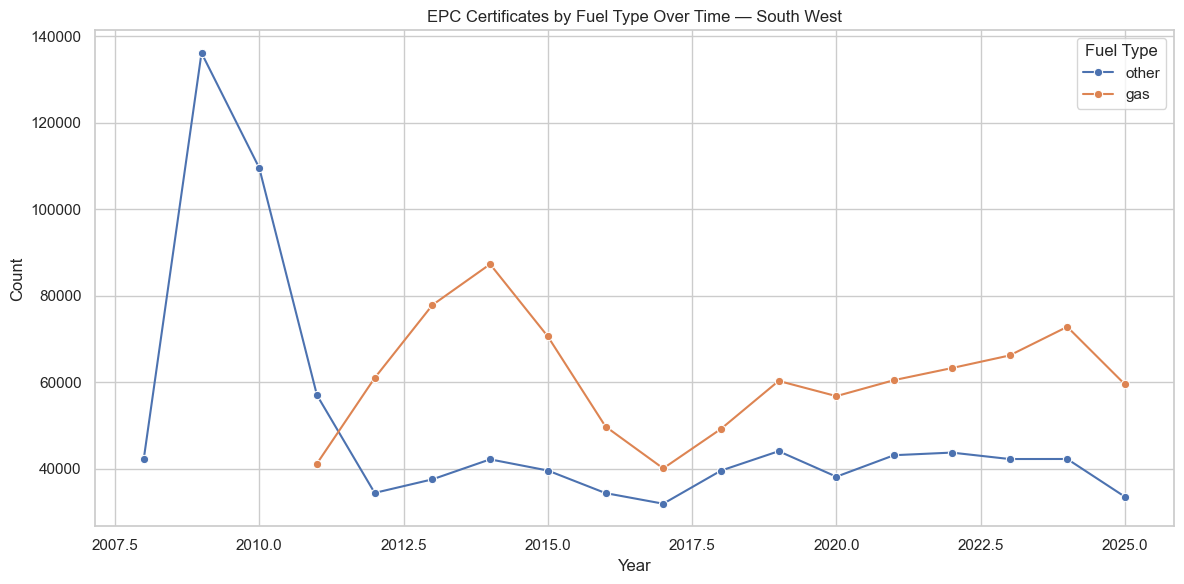

In [249]:
fuel_year = (
    df.groupby(["YEAR", "MAIN_FUEL_STD"])["LMK_KEY"]
      .count()
      .reset_index(name="cert_count")
)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.lineplot(
    data=fuel_year,
    x="YEAR",
    y="cert_count",
    hue="MAIN_FUEL_STD",
    marker="o"
)

plt.title("EPC Certificates by Fuel Type Over Time — South West")
plt.xlabel("Year")
plt.ylabel("Count")
plt.legend(title="Fuel Type")
plt.tight_layout()
plt.show()

<Axes: xlabel='MAIN_FUEL_STD', ylabel='CURRENT_ENERGY_EFFICIENCY'>

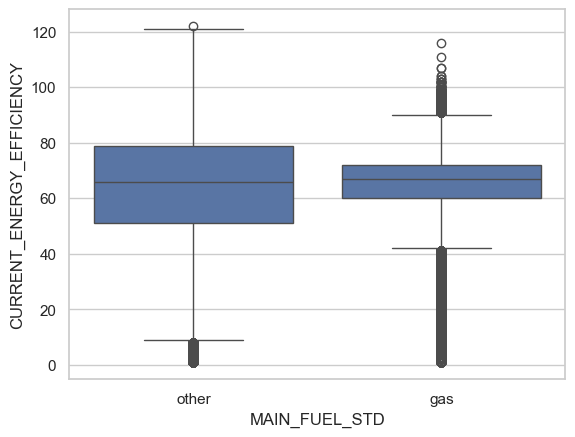

In [250]:
sns.boxplot(
    data=df,
    x="MAIN_FUEL_STD",
    y="CURRENT_ENERGY_EFFICIENCY",
)

In [251]:
# 2. MISSING DATA PATTERNS -------------------------------------------------
missing_pct = df.isna().mean().sort_values(ascending=False) * 100
missing_pct

FLOOR_HEIGHT                   44.230505
MAIN_HEATING_CONTROLS          38.872485
MAINS_GAS_FLAG                 12.460451
NUMBER_HABITABLE_ROOMS         12.280130
NUMBER_HEATED_ROOMS            12.280130
MECHANICAL_VENTILATION          5.506204
TENURE                          2.358277
CONSTRUCTION_AGE_BAND           0.868085
MAIN_FUEL                       0.312298
BUILT_FORM                      0.017202
TENURE_STD                      0.000000
MAIN_FUEL_STD                   0.000000
AGE_BAND_STD                    0.000000
EFFICIENCY_GAP                  0.000000
EPC_BAND_SCORE                  0.000000
HAS_MAINS_GAS                   0.000000
IS_ELECTRIC_HEAT                0.000000
YEAR                            0.000000
LMK_KEY                         0.000000
TRANSACTION_TYPE                0.000000
POSTCODE                        0.000000
PROPERTY_TYPE                   0.000000
TOTAL_FLOOR_AREA                0.000000
CO2_EMISSIONS_CURRENT           0.000000
ENERGY_CONSUMPTI

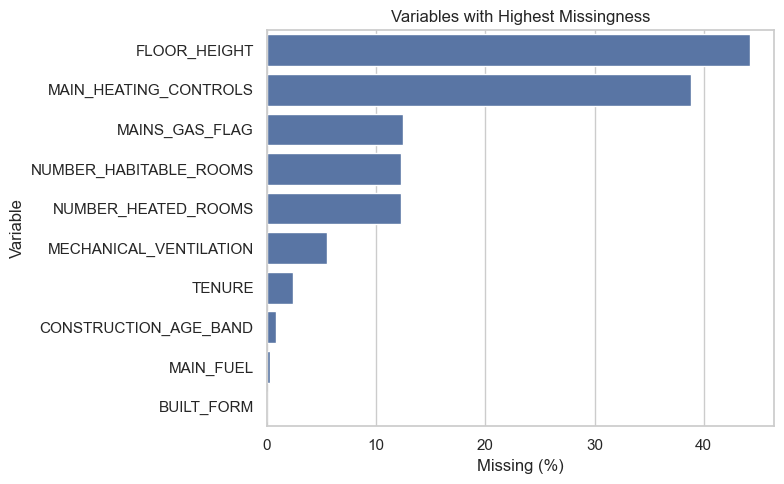

In [252]:
top_miss = missing_pct[missing_pct > 0].head(10)

plt.figure(figsize=(8,5))
sns.barplot(
    x=top_miss.values,
    y=top_miss.index,
    orient="h"
)
plt.xlabel("Missing (%)")
plt.ylabel("Variable")
plt.title("Variables with Highest Missingness")
plt.tight_layout()
plt.show()

In [253]:
import pandas as pd

# df = pd.read_csv("data/processed/ew_epc_core_clean_sw.csv")

# -------------------------
# A: Drop high-missingness variables
# -------------------------
drop_cols = ["FLOOR_HEIGHT", "MAIN_HEATING_CONTROLS"]
df = df.drop(columns=drop_cols, errors="ignore")

# -------------------------
# B: Impute <5% missing variables as "Unknown"
# -------------------------
minor_cats = ["CONSTRUCTION_AGE_BAND", "MAIN_FUEL", "BUILT_FORM"]
for col in minor_cats:
    df[col] = df[col].fillna("Unknown")

# -------------------------
# C: Moderate missingness → impute + create flags
# -------------------------
moderate_cols = [
    "NUMBER_HABITABLE_ROOMS",
    "NUMBER_HEATED_ROOMS",
    "MAINS_GAS_FLAG",
    "MECHANICAL_VENTILATION",
    "TENURE"
]

for col in moderate_cols:
    df[f"{col}_MISSING"] = df[col].isna().astype(int)
    # categorical imputation
    if df[col].dtype == "object":
        df[col] = df[col].fillna("Unknown")
    else:
        df[col] = df[col].fillna(df[col].median())


# ----------------------------
# SAVE cleaned version
# ----------------------------
OUTPUT_PATH = Path("/Users/divyanshu/Desktop/Dissertation_production-ready/ew-housing-energy-impact/data/processed/ew_epc_core_clean_sw/ew_epc_core_clean_sw_imputed.csv")
df.to_csv(OUTPUT_PATH, index=False)

print("✓ Missing-value cleaning complete.")
print(f"Saved to: {OUTPUT_PATH}")

✓ Missing-value cleaning complete.
Saved to: /Users/divyanshu/Desktop/Dissertation_production-ready/ew-housing-energy-impact/data/processed/ew_epc_core_clean_sw/ew_epc_core_clean_sw_imputed.csv


A detailed missingness audit revealed several clear patterns (Figure X). Variables such as floor height and heating control type exhibited very high missingness (>40%), largely due to inconsistent adoption of EPC software fields over time. These were excluded from all modelling specifications to avoid non-random missingness biases.

Variables with moderate missingness (10–15%) — namely the room count variables, mains-gas flag, mechanical ventilation, and tenure — were retained due to their theoretical relevance. Missing values were encoded as an explicit "Unknown" category, and binary missingness indicators were created for each variable to preserve information about assessor omission patterns.

Variables with <5% missingness (construction age band, main fuel, built form) were simply imputed as "Unknown". All outcome variables (EPC efficiency score, CO₂ emissions) and key engineered predictors exhibited no missingness. This approach ensures both maximum sample retention and transparency, while avoiding unjustified numerical imputation or listwise deletion.


In [254]:
# Load the imputed dataset
IMPUTED_PATH = Path("/Users/divyanshu/Desktop/Dissertation_production-ready/ew-housing-energy-impact/data/processed/ew_epc_core_clean_sw/ew_epc_core_clean_sw_imputed.csv")
df = pd.read_csv(IMPUTED_PATH)

# Recalculate missingness %
missing_percent = df.isna().mean().sort_values(ascending=False) * 100

missing_percent.head(20)

LMK_KEY                           0.0
POSTCODE                          0.0
NUMBER_HEATED_ROOMS               0.0
MECHANICAL_VENTILATION            0.0
YEAR                              0.0
MAIN_FUEL_STD                     0.0
TENURE_STD                        0.0
AGE_BAND_STD                      0.0
EFFICIENCY_GAP                    0.0
EPC_BAND_SCORE                    0.0
HAS_MAINS_GAS                     0.0
IS_ELECTRIC_HEAT                  0.0
BELOW_C                           0.0
NUMBER_HABITABLE_ROOMS_MISSING    0.0
NUMBER_HEATED_ROOMS_MISSING       0.0
MAINS_GAS_FLAG_MISSING            0.0
MECHANICAL_VENTILATION_MISSING    0.0
NUMBER_HABITABLE_ROOMS            0.0
TRANSACTION_TYPE                  0.0
TENURE                            0.0
dtype: float64

In [255]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# # 🔁 1. Load the cleaned South-West EPC data
# PATH_CLEAN = "data/processed/ew_epc_core_clean_sw/ew_epc_core_clean_sw.csv"
# df = pd.read_csv(PATH_CLEAN)

# Quick sanity check
print(df.shape)
print(df[["YEAR", "CURRENT_ENERGY_EFFICIENCY", "CO2_EMISSIONS_CURRENT"]].head())

(1807888, 36)
   YEAR  CURRENT_ENERGY_EFFICIENCY  CO2_EMISSIONS_CURRENT
0  2008                         84                    1.4
1  2008                         69                    2.8
2  2008                         58                    4.6
3  2008                         44                    4.6
4  2008                         57                    6.2


In [256]:
df

,LMK_KEY,POSTCODE,LOCAL_AUTHORITY,LOCAL_AUTHORITY_LABEL,LODGEMENT_DATE,CURRENT_ENERGY_RATING,CURRENT_ENERGY_EFFICIENCY,POTENTIAL_ENERGY_RATING,POTENTIAL_ENERGY_EFFICIENCY,ENERGY_CONSUMPTION_CURRENT,...,EFFICIENCY_GAP,EPC_BAND_SCORE,HAS_MAINS_GAS,IS_ELECTRIC_HEAT,BELOW_C,NUMBER_HABITABLE_ROOMS_MISSING,NUMBER_HEATED_ROOMS_MISSING,MAINS_GAS_FLAG_MISSING,MECHANICAL_VENTILATION_MISSING,TENURE_MISSING
0,29087020002008100209344654182258,BH1 3QF,E06000058,"Bournemouth, Christchurch and Poole",2008-10-02 00:00:00+00:00,B,84,B,85,132,...,1,6,False,False,False,1,1,1,0,1
1,162691330702008101308085753289378,SN5 5RZ,E06000030,Swindon,2008-10-13 00:00:00+00:00,C,69,C,76,275,...,7,5,True,False,False,0,0,0,0,0
2,177427449952008110523461208089155,BA1 6JH,E06000022,Bath and North East Somerset,2008-11-05 00:00:00+00:00,D,58,D,62,424,...,4,4,False,False,True,0,0,1,0,0
3,37743650742008111311541854389578,PL14 4NP,E06000052,Cornwall,2008-11-13 00:00:00+00:00,E,44,E,52,549,...,8,3,False,False,True,0,0,0,0,0
4,158859350832008101718063789968495,PL26 8EY,E06000052,Cornwall,2008-10-17 00:00:00+00:00,D,57,D,59,471,...,2,4,False,False,True,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1807883,03c5078838a4bccc40c0f49c4c625b90643adc2c6782f3...,PL18 9FX,E06000052,Cornwall,2025-09-27 00:00:00+00:00,B,81,B,83,42,...,2,6,False,False,False,1,1,1,1,0
1807884,03f441b2da88c81db1bda5f034684b7a1b29a2934e0646...,BA3 4HQ,E06000066,Somerset,2025-09-25 00:00:00+00:00,D,55,D,67,297,...,12,4,True,False,True,0,0,0,1,0
1807885,03f5764afc2d5ac08ad7d036df1514bab2651dc42d604c...,TA4 3JJ,E06000066,Somerset,2025-09-10 00:00:00+00:00,F,27,D,57,236,...,30,2,False,False,True,0,0,0,1,0
1807886,03f62c5b45b13282b4b2647422f2e927a88bdf3d5ae7c6...,TQ1 4AL,E06000027,Torbay,2025-09-09 00:00:00+00:00,C,71,C,75,164,...,4,5,False,False,False,0,0,0,1,0


In [257]:
def policy_period_from_year(y: int) -> str:
    if y <= 2012:
        return "Pre-GreenDeal (≤2012)"
    elif 2013 <= y <= 2015:
        return "GreenDeal/ECO (2013–2015)"
    elif 2016 <= y <= 2019:
        return "MEES era (2016–2019)"
    else:
        return "Post-Strategy (2020–2025)"

df["POLICY_PERIOD"] = df["YEAR"].apply(policy_period_from_year)
df["POLICY_PERIOD"] = pd.Categorical(
    df["POLICY_PERIOD"],
    categories=[
        "Pre-GreenDeal (≤2012)",
        "GreenDeal/ECO (2013–2015)",
        "MEES era (2016–2019)",
        "Post-Strategy (2020–2025)",
    ],
    ordered=True,
)

df["YEAR"].min(), df["YEAR"].max()

(np.int64(2008), np.int64(2025))

In [258]:
eff_trend = (
    df.groupby("YEAR", as_index=False)
      .agg(mean_eff=("CURRENT_ENERGY_EFFICIENCY", "mean"),
           median_eff=("CURRENT_ENERGY_EFFICIENCY", "median"),
           n=("LMK_KEY", "count"))
)

eff_trend.head()

,YEAR,mean_eff,median_eff,n
0,2008,61.132822,64.0,42335
1,2009,61.671168,64.0,136106
2,2010,61.526939,64.0,109542
3,2011,62.039387,65.0,98204
4,2012,63.656725,66.0,95390


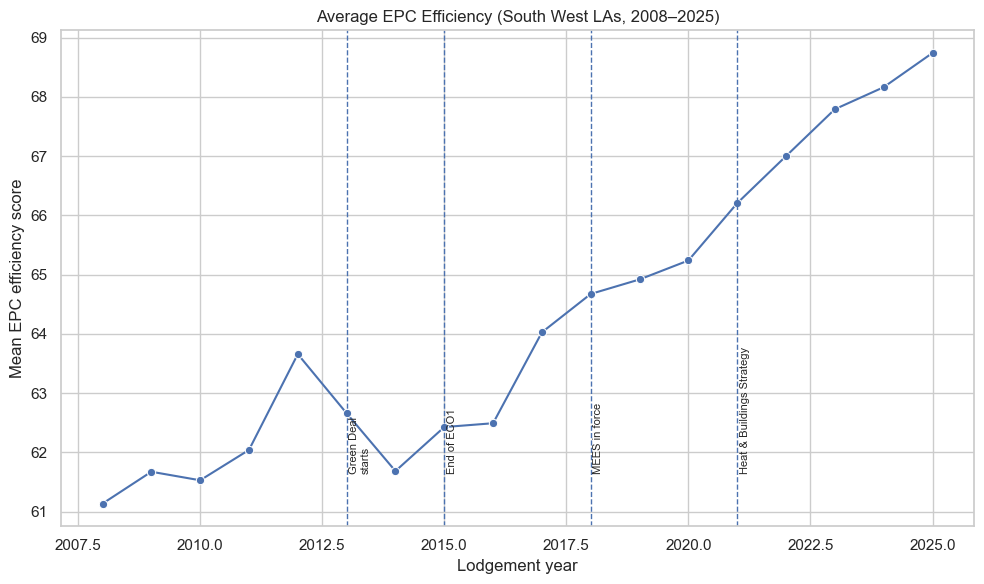

In [259]:
plt.figure(figsize=(10, 6))

ax = sns.lineplot(
    data=eff_trend,
    x="YEAR",
    y="mean_eff",
    marker="o",
)

# Policy vertical lines
for x, label in [(2013, "Green Deal\nstarts"),
                 (2015, "End of ECO1"),
                 (2018, "MEES in force"),
                 (2021, "Heat & Buildings Strategy")]:
    plt.axvline(x=x, linestyle="--", linewidth=1)
    plt.text(x+0.05, eff_trend["mean_eff"].min()+0.5, label,
             rotation=90, va="bottom", ha="left", fontsize=8)

plt.title("Average EPC Efficiency (South West LAs, 2008–2025)")
plt.xlabel("Lodgement year")
plt.ylabel("Mean EPC efficiency score")
plt.tight_layout()
plt.show()

When you look at the plot, ask:
#### Is the line generally upward?
- That would suggest gradual improvement in housing efficiency over time.
- You can phrase it as:
- “Between 2008–2025, average EPC efficiency in South West local authorities rose from approximately X to Y, indicating a general improvement in the thermal performance of the housing stock.”
#### Do you see noticeable changes in slope around policy dates?
- e.g. a steeper rise 2013–2015, or 2016–2019.
- Then you can write:
- “Visually, the increase in EPC scores accelerates during the Green Deal/ECO period and remains elevated during the early MEES years, which is consistent with policies targeting retrofit and rental standards.”
#### Does the line flatten or dip in the post-2020 period?
- Maybe COVID or data artefacts change the pattern.
- That’s important to mention as a limitation or confounder.

In [260]:
co2_trend = (
    df.groupby("YEAR", as_index=False)
      .agg(mean_co2=("CO2_EMISSIONS_CURRENT", "mean"),
           median_co2=("CO2_EMISSIONS_CURRENT", "median"),
           n=("LMK_KEY", "count"))
)

co2_trend.head()

,YEAR,mean_co2,median_co2,n
0,2008,4.253620,3.4,42335
1,2009,4.271804,3.5,136106
2,2010,4.435477,3.7,109542
3,2011,4.427212,3.7,98204
4,2012,4.037303,3.4,95390


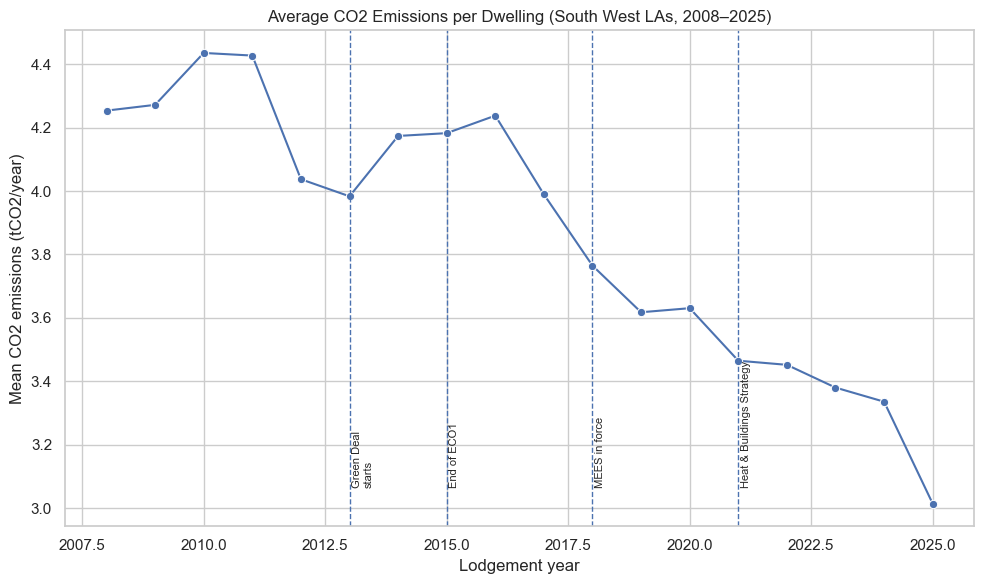

In [261]:
plt.figure(figsize=(10, 6))

ax = sns.lineplot(
    data=co2_trend,
    x="YEAR",
    y="mean_co2",
    marker="o",
)

for x, label in [(2013, "Green Deal\nstarts"),
                 (2015, "End of ECO1"),
                 (2018, "MEES in force"),
                 (2021, "Heat & Buildings Strategy")]:
    plt.axvline(x=x, linestyle="--", linewidth=1)
    plt.text(x+0.05, co2_trend["mean_co2"].min()+0.05, label,
             rotation=90, va="bottom", ha="left", fontsize=8)

plt.title("Average CO2 Emissions per Dwelling (South West LAs, 2008–2025)")
plt.xlabel("Lodgement year")
plt.ylabel("Mean CO2 emissions (tCO2/year)")
plt.tight_layout()
plt.show()

/var/folders/gs/6gjhnpdn0zd0p99jkjwdr0700000gn/T/ipykernel_1044/2317106262.py:19: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.tight_layout()
/Users/divyanshu/.pyenv/versions/3.11.9/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


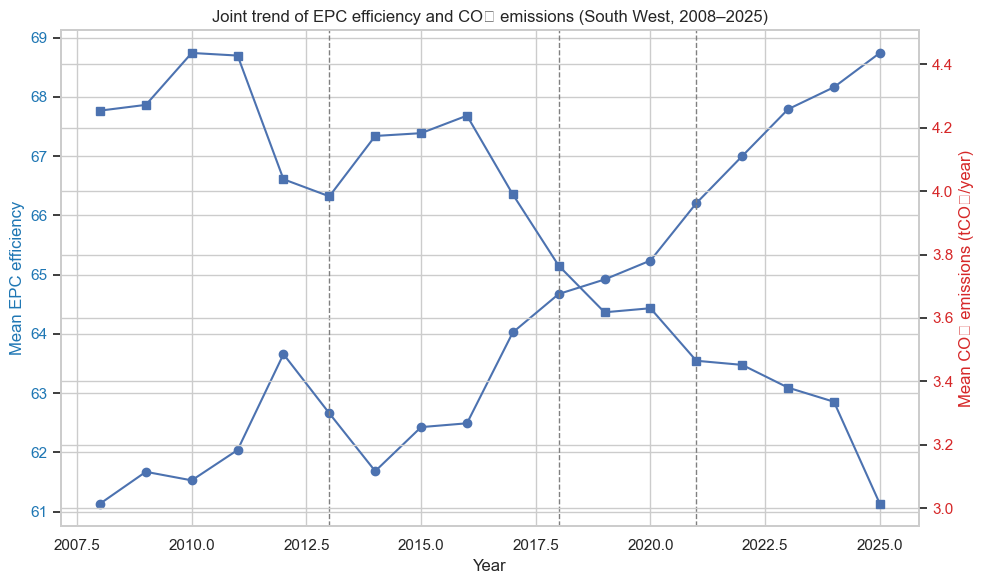

In [262]:
fig, ax1 = plt.subplots(figsize=(10, 6))

color1 = "tab:blue"
ax1.set_xlabel("Year")
ax1.set_ylabel("Mean EPC efficiency", color=color1)
ax1.plot(eff_trend["YEAR"], eff_trend["mean_eff"], marker="o")
ax1.tick_params(axis="y", labelcolor=color1)

ax2 = ax1.twinx()
color2 = "tab:red"
ax2.set_ylabel("Mean CO₂ emissions (tCO₂/year)", color=color2)
ax2.plot(co2_trend["YEAR"], co2_trend["mean_co2"], marker="s")
ax2.tick_params(axis="y", labelcolor=color2)

for x in [2013, 2018, 2021]:
    ax1.axvline(x=x, linestyle="--", linewidth=1, color="grey")

plt.title("Joint trend of EPC efficiency and CO₂ emissions (South West, 2008–2025)")
fig.tight_layout()
plt.show()

In [263]:
import pandas as pd

# Load your cleaned South West dataset
df = pd.read_csv(
    "/Users/divyanshu/Desktop/Dissertation_production-ready/ew-housing-energy-impact/data/processed/ew_epc_core_clean_sw/ew_epc_core_clean_sw.csv"
)

# Define function for policy period assignment
def policy_period(year):
    if 2008 <= year <= 2012:
        return "Pre-GreenDeal"
    elif 2013 <= year <= 2014:
        return "GreenDeal-ECO1"
    elif 2015 <= year <= 2017:
        return "ECO2"
    elif 2018 <= year <= 2020:
        return "MEES"
    elif 2021 <= year <= 2025:
        return "Post-Strategy"
    else:
        return "Other"

# Apply
df["POLICY_PERIOD"] = df["YEAR"].apply(policy_period)

df.head()

/var/folders/gs/6gjhnpdn0zd0p99jkjwdr0700000gn/T/ipykernel_1044/1190841144.py:4: DtypeWarning: Columns (23) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


,LMK_KEY,POSTCODE,LOCAL_AUTHORITY,LOCAL_AUTHORITY_LABEL,LODGEMENT_DATE,CURRENT_ENERGY_RATING,CURRENT_ENERGY_EFFICIENCY,POTENTIAL_ENERGY_RATING,POTENTIAL_ENERGY_EFFICIENCY,ENERGY_CONSUMPTION_CURRENT,...,YEAR,MAIN_FUEL_STD,TENURE_STD,AGE_BAND_STD,EFFICIENCY_GAP,EPC_BAND_SCORE,HAS_MAINS_GAS,IS_ELECTRIC_HEAT,BELOW_C,POLICY_PERIOD
0,29087020002008100209344654182258,BH1 3QF,E06000058,"Bournemouth, Christchurch and Poole",2008-10-02 00:00:00+00:00,B,84,B,85,132,...,2008,other,Unknown,NO DATA!,1,6,False,False,False,Pre-GreenDeal
1,162691330702008101308085753289378,SN5 5RZ,E06000030,Swindon,2008-10-13 00:00:00+00:00,C,69,C,76,275,...,2008,other,Rented (private),England and Wales: 1983-1990,7,5,True,False,False,Pre-GreenDeal
2,177427449952008110523461208089155,BA1 6JH,E06000022,Bath and North East Somerset,2008-11-05 00:00:00+00:00,D,58,D,62,424,...,2008,other,Unknown,England and Wales: 1967-1975,4,4,False,False,True,Pre-GreenDeal
3,37743650742008111311541854389578,PL14 4NP,E06000052,Cornwall,2008-11-13 00:00:00+00:00,E,44,E,52,549,...,2008,other,Owner-occupied,England and Wales: 1996-2002,8,3,False,False,True,Pre-GreenDeal
4,158859350832008101718063789968495,PL26 8EY,E06000052,Cornwall,2008-10-17 00:00:00+00:00,D,57,D,59,471,...,2008,other,Unknown,England and Wales: 1983-1990,2,4,False,False,True,Pre-GreenDeal


In [264]:
df["POLICY_PERIOD"].value_counts()

POLICY_PERIOD
Post-Strategy     527114
Pre-GreenDeal     481577
MEES              288066
ECO2              266294
GreenDeal-ECO1    244837
Name: count, dtype: int64

In [265]:
df.to_csv(
    "/Users/divyanshu/Desktop/Dissertation_production-ready/ew-housing-energy-impact/data/processed/ew_epc_core_clean_sw/ew_epc_core_clean_sw_with_policy.csv",
    index=False
)

/var/folders/gs/6gjhnpdn0zd0p99jkjwdr0700000gn/T/ipykernel_1044/3442410805.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=policy_summary, x="POLICY_PERIOD", y="mean", palette="viridis")


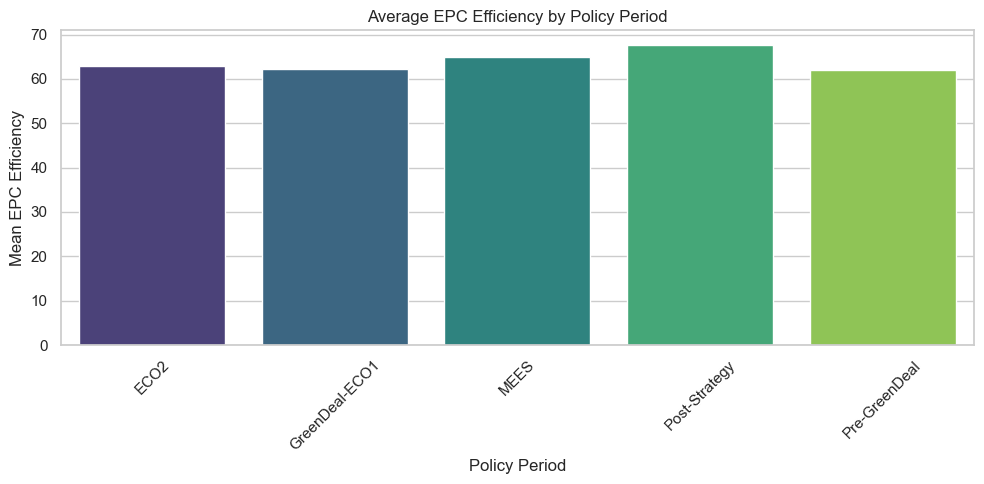

,POLICY_PERIOD,mean,median,count
0,ECO2,62.878142,65.0,266294
1,GreenDeal-ECO1,62.142233,64.0,244837
2,MEES,64.946918,67.0,288066
3,Post-Strategy,67.566572,70.0,527114
4,Pre-GreenDeal,62.059419,65.0,481577


In [266]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


policy_summary = df.groupby("POLICY_PERIOD")["CURRENT_ENERGY_EFFICIENCY"].agg(["mean","median","count"]).reset_index()

plt.figure(figsize=(10,5))
sns.barplot(data=policy_summary, x="POLICY_PERIOD", y="mean", palette="viridis")
plt.title("Average EPC Efficiency by Policy Period")
plt.ylabel("Mean EPC Efficiency")
plt.xlabel("Policy Period")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

policy_summary

/var/folders/gs/6gjhnpdn0zd0p99jkjwdr0700000gn/T/ipykernel_1044/387146962.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["POLICY_PERIOD", "CURRENT_ENERGY_RATING"])["LMK_KEY"]


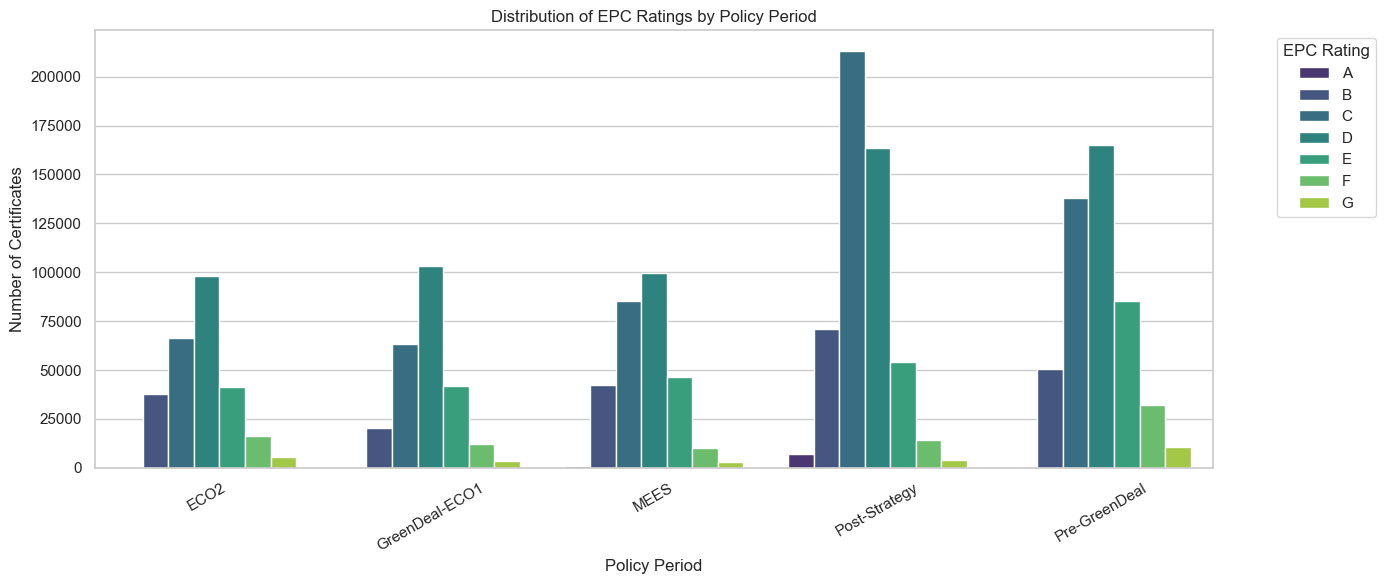

In [267]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure correct order of EPC bands
rating_order = ["A", "B", "C", "D", "E", "F", "G"]

df["CURRENT_ENERGY_RATING"] = pd.Categorical(
    df["CURRENT_ENERGY_RATING"], 
    categories=rating_order, 
    ordered=True
)

rating_policy = (
    df.groupby(["POLICY_PERIOD", "CURRENT_ENERGY_RATING"])["LMK_KEY"]
      .count()
      .reset_index()
)

plt.figure(figsize=(14,6))
sns.barplot(
    data=rating_policy,
    x="POLICY_PERIOD",
    y="LMK_KEY",
    hue="CURRENT_ENERGY_RATING",
    palette="viridis"
)

plt.title("Distribution of EPC Ratings by Policy Period")
plt.xlabel("Policy Period")
plt.ylabel("Number of Certificates")
plt.legend(title="EPC Rating", bbox_to_anchor=(1.05,1), loc="upper left")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

/var/folders/gs/6gjhnpdn0zd0p99jkjwdr0700000gn/T/ipykernel_1044/3119451284.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=co2_period, x="POLICY_PERIOD", y="CO2_EMISSIONS_CURRENT", palette="viridis")


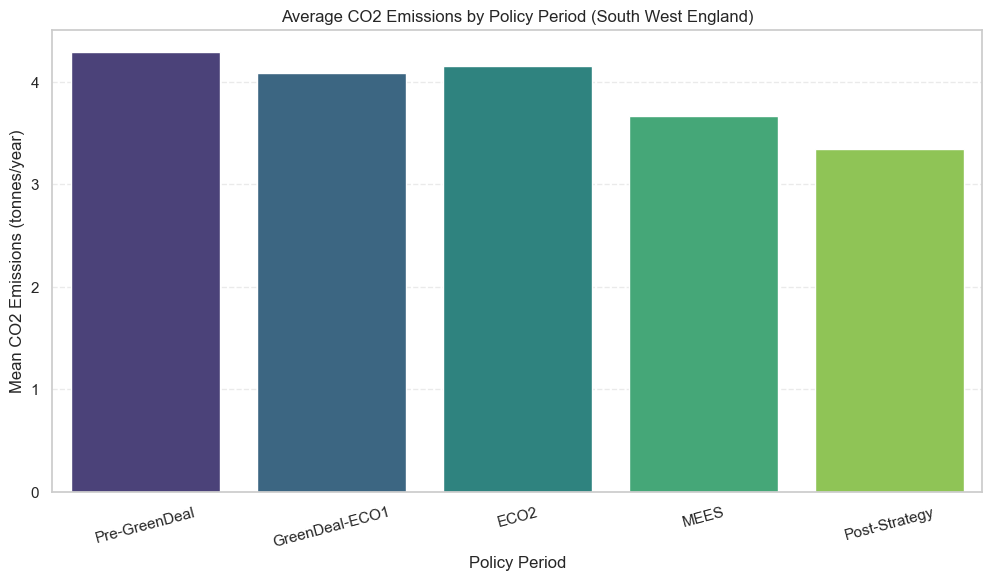

In [268]:
# Compute mean CO2 emissions per policy period
co2_period = df.groupby("POLICY_PERIOD")["CO2_EMISSIONS_CURRENT"].mean().reset_index()

# Sort in policy timeline order
policy_order = ["Pre-GreenDeal", "GreenDeal-ECO1", "ECO2", "MEES", "Post-Strategy"]
co2_period["POLICY_PERIOD"] = pd.Categorical(co2_period["POLICY_PERIOD"], categories=policy_order, ordered=True)
co2_period = co2_period.sort_values("POLICY_PERIOD")

plt.figure(figsize=(12,6))
sns.barplot(data=co2_period, x="POLICY_PERIOD", y="CO2_EMISSIONS_CURRENT", palette="viridis")

plt.title("Average CO2 Emissions by Policy Period (South West England)")
plt.ylabel("Mean CO2 Emissions (tonnes/year)")
plt.xlabel("Policy Period")
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

## Trends over Time and Policy Period

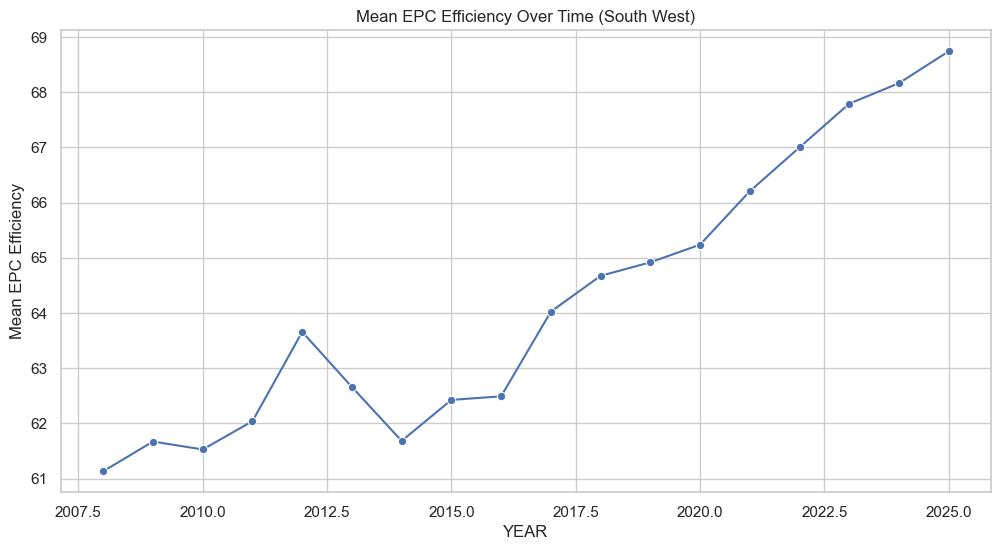

In [269]:
yearly = (
    df.groupby("YEAR")["CURRENT_ENERGY_EFFICIENCY"]
      .agg(["mean", "median", "count"])
      .reset_index()
)

plt.figure(figsize=(12,6))
sns.lineplot(data=yearly, x="YEAR", y="mean", marker="o")
plt.title("Mean EPC Efficiency Over Time (South West)")
plt.ylabel("Mean EPC Efficiency")
plt.grid(True)
plt.show()

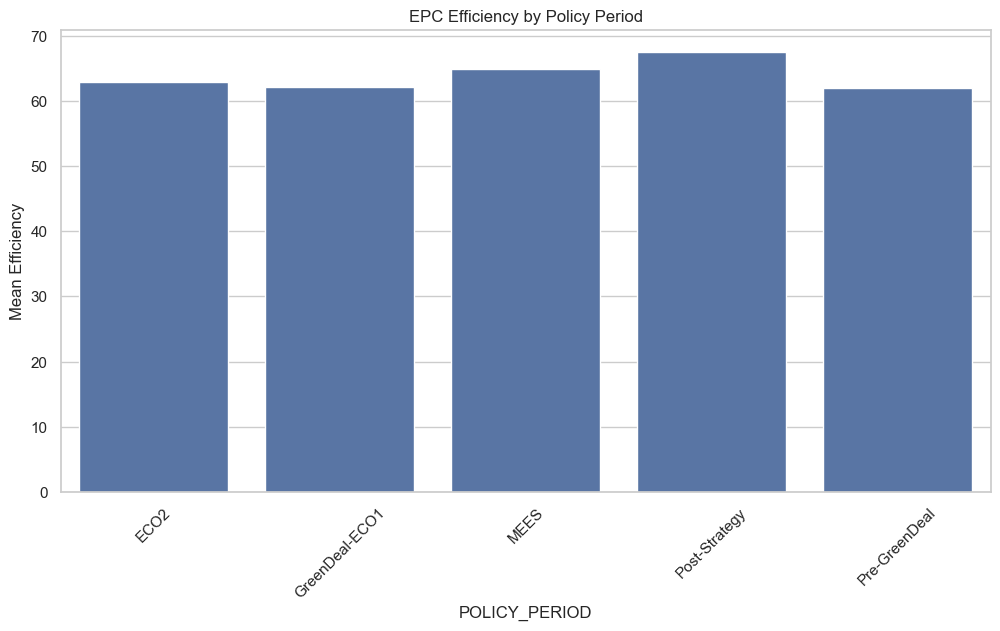

In [270]:
pp = (
    df.groupby("POLICY_PERIOD")["CURRENT_ENERGY_EFFICIENCY"]
      .agg(["mean", "median", "count"])
      .reset_index()
)

plt.figure(figsize=(12,6))
sns.barplot(data=pp, x="POLICY_PERIOD", y="mean")
plt.title("EPC Efficiency by Policy Period")
plt.xticks(rotation=45)
plt.ylabel("Mean Efficiency")
plt.show()

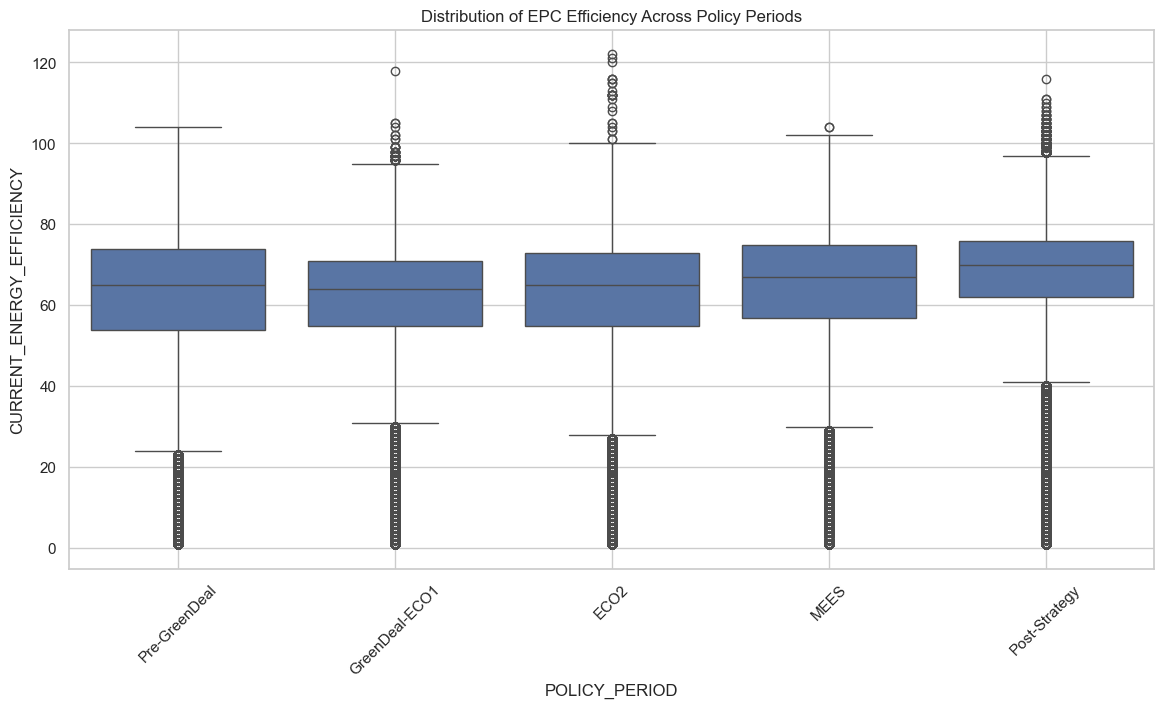

In [271]:
plt.figure(figsize=(14,7))
sns.boxplot(data=df, x="POLICY_PERIOD", y="CURRENT_ENERGY_EFFICIENCY")
plt.title("Distribution of EPC Efficiency Across Policy Periods")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

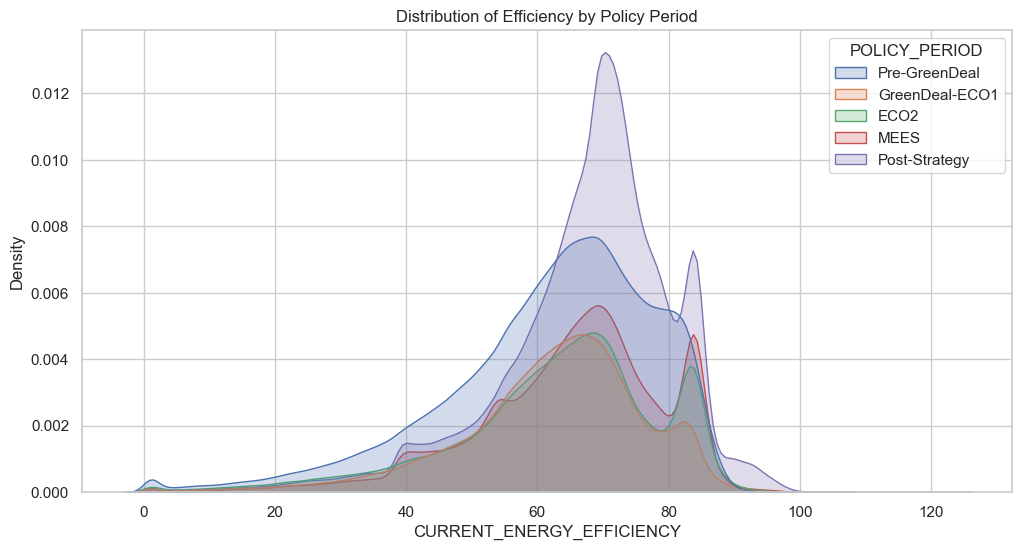

In [272]:
plt.figure(figsize=(12,6))
sns.kdeplot(data=df, x="CURRENT_ENERGY_EFFICIENCY", hue="POLICY_PERIOD", fill=True)
plt.title("Distribution of Efficiency by Policy Period")
plt.show()

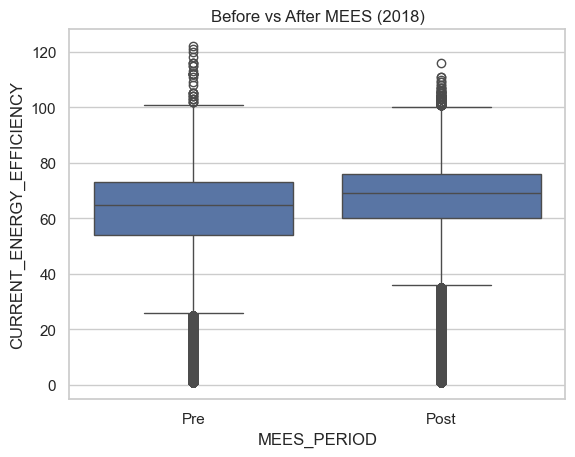

In [273]:
df["MEES_PERIOD"] = df["YEAR"].apply(lambda y: "Pre" if y < 2018 else "Post")

sns.boxplot(data=df, x="MEES_PERIOD", y="CURRENT_ENERGY_EFFICIENCY")
plt.title("Before vs After MEES (2018)")
plt.show()

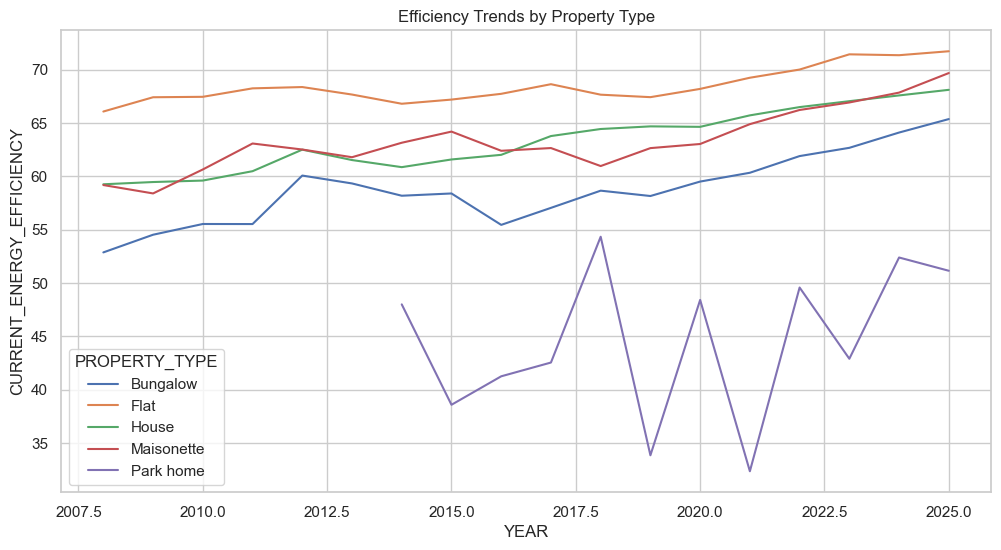

In [274]:
pt = (
    df.groupby(["YEAR", "PROPERTY_TYPE"])["CURRENT_ENERGY_EFFICIENCY"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(12,6))
sns.lineplot(data=pt, x="YEAR", y="CURRENT_ENERGY_EFFICIENCY", hue="PROPERTY_TYPE")
plt.title("Efficiency Trends by Property Type")
plt.show()

In [275]:
top_types = (
    df["PROPERTY_TYPE"]
    .value_counts()
    .head(5)
    .index
)

df2 = df[df["PROPERTY_TYPE"].isin(top_types)]

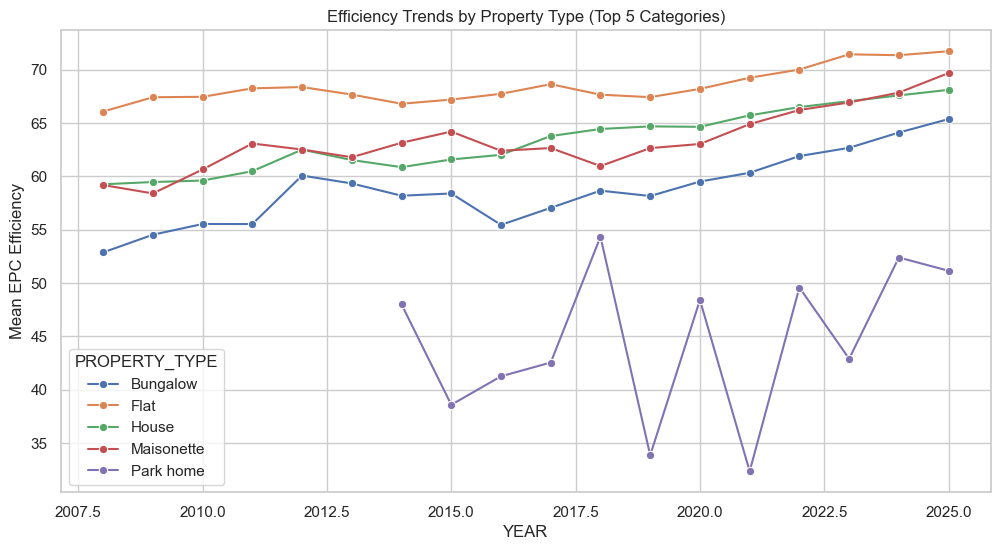

In [276]:
pt = (
    df2.groupby(["YEAR", "PROPERTY_TYPE"])["CURRENT_ENERGY_EFFICIENCY"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(12,6))
sns.lineplot(
    data=pt,
    x="YEAR",
    y="CURRENT_ENERGY_EFFICIENCY",
    hue="PROPERTY_TYPE",
    marker="o"
)
plt.title("Efficiency Trends by Property Type (Top 5 Categories)")
plt.ylabel("Mean EPC Efficiency")
plt.show()

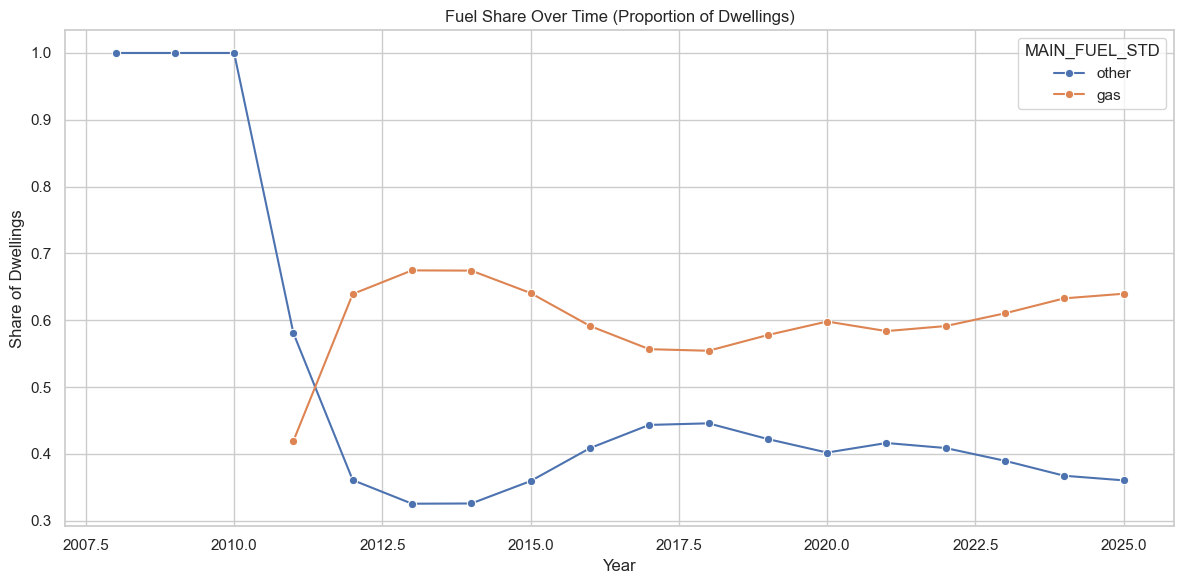

In [277]:
# 1. Count certificates by YEAR × MAIN_FUEL_STD
fuel_year = (
    df.groupby(["YEAR", "MAIN_FUEL_STD"], as_index=False)
      .agg(count=("LMK_KEY", "size"))
)

# 2. Compute within-year fuel share
fuel_year["fuel_share"] = (
    fuel_year["count"] /
    fuel_year.groupby("YEAR")["count"].transform("sum")
)

# 3. Plot
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=fuel_year,
    x="YEAR",
    y="fuel_share",
    hue="MAIN_FUEL_STD",
    marker="o"
)
plt.title("Fuel Share Over Time (Proportion of Dwellings)")
plt.ylabel("Share of Dwellings")
plt.xlabel("Year")
plt.tight_layout()
plt.show()

In [278]:
!pip install statsmodels

In [279]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.multicomp import pairwise_tukeyhsd

In [280]:
def eta_squared(anova_table):
    """
    η² = SS_effect / (SS_effect + SS_error)
    Assumes last row of anova_table is the residual.
    """
    ss_effect = anova_table['sum_sq'].iloc[:-1].sum()
    ss_error  = anova_table['sum_sq'].iloc[-1]
    return ss_effect / (ss_effect + ss_error)


def omega_squared(anova_table):
    """
    ω² using:
    ω² = (SS_effect - df_effect * MS_error) / (SS_effect + SS_error + MS_error)
    Assumes last row of anova_table is the residual.
    """
    # Split effect vs residual
    ss_effect = anova_table['sum_sq'].iloc[:-1].sum()
    df_effect = anova_table['df'].iloc[:-1].sum()

    ss_error  = anova_table['sum_sq'].iloc[-1]
    df_error  = anova_table['df'].iloc[-1]
    ms_error  = ss_error / df_error

    return (ss_effect - df_effect * ms_error) / (ss_effect + ss_error + ms_error)

In [281]:
# Drop missing outcome or policy labels
df_pp = df.dropna(subset=["CURRENT_ENERGY_EFFICIENCY", "POLICY_PERIOD"]).copy()

# Treat POLICY_PERIOD as categorical with an ordered category (optional)
df_pp["POLICY_PERIOD"] = pd.Categorical(
    df_pp["POLICY_PERIOD"],
    categories=["Pre-GreenDeal", "GreenDeal-ECO1", "ECO2", "MEES", "Post-Strategy"],
    ordered=True
)

# Fit one-way ANOVA model: Efficiency ~ PolicyPeriod
model_pp = ols("CURRENT_ENERGY_EFFICIENCY ~ C(POLICY_PERIOD)", data=df_pp).fit()
anova_pp = anova_lm(model_pp, typ=2)
print("ANOVA: Efficiency ~ Policy Period")
print(anova_pp)

print("\nEffect sizes:")
print("η² =", eta_squared(anova_pp))
print("ω² =", omega_squared(anova_pp))

# Post-hoc pairwise comparisons (Tukey)
tukey_pp = pairwise_tukeyhsd(
    endog=df_pp["CURRENT_ENERGY_EFFICIENCY"],
    groups=df_pp["POLICY_PERIOD"],
    alpha=0.05
)
print("\nTukey HSD pairwise comparisons between policy periods:")
print(tukey_pp)

ANOVA: Efficiency ~ Policy Period
                        sum_sq         df             F  PR(>F)
C(POLICY_PERIOD)  9.837705e+06        4.0  11035.392336     0.0
Residual          4.029177e+08  1807883.0           NaN     NaN

Effect sizes:
η² = 0.023834224488253928
ω² = 0.023832051821585015

Tukey HSD pairwise comparisons between policy periods:
        Multiple Comparison of Means - Tukey HSD, FWER=0.05         
    group1         group2     meandiff p-adj   lower   upper  reject
--------------------------------------------------------------------
          ECO2 GreenDeal-ECO1  -0.7359    0.0 -0.8499 -0.6219   True
          ECO2           MEES   2.0688    0.0  1.9593  2.1782   True
          ECO2  Post-Strategy   4.6884    0.0  4.5916  4.7852   True
          ECO2  Pre-GreenDeal  -0.8187    0.0 -0.9171 -0.7204   True
GreenDeal-ECO1           MEES   2.8047    0.0  2.6927  2.9166   True
GreenDeal-ECO1  Post-Strategy   5.4243    0.0  5.3247  5.5239   True
GreenDeal-ECO1  Pre-GreenDeal 

In [282]:
# We keep only gas vs other (you already mapped this)
df_fuel = df.dropna(subset=["CURRENT_ENERGY_EFFICIENCY", "MAIN_FUEL_STD"]).copy()

gas_eff   = df_fuel.loc[df_fuel["MAIN_FUEL_STD"] == "gas", "CURRENT_ENERGY_EFFICIENCY"]
other_eff = df_fuel.loc[df_fuel["MAIN_FUEL_STD"] == "other", "CURRENT_ENERGY_EFFICIENCY"]

# Check normality roughly (optional quick view)
print("Gas mean, std:", gas_eff.mean(), gas_eff.std())
print("Other mean, std:", other_eff.mean(), other_eff.std())

# Welch t-test (default unequal variances)
t_stat, p_val = stats.ttest_ind(gas_eff, other_eff, equal_var=False)
print("\nWelch t-test: gas vs other")
print("t-statistic:", t_stat, "p-value:", p_val)

d = cohens_d(gas_eff, other_eff)
print("Cohen's d:", d)

Gas mean, std: 65.53220777037905 9.853899836504267
Other mean, std: 62.94667616201152 18.966895733075145

Welch t-test: gas vs other
t-statistic: 114.55342672080033 p-value: 0.0
Cohen's d: 0.17174498975394256


In [283]:
# Focus on main property groups (drop rare types if you want)
df_pt = df.dropna(subset=["CURRENT_ENERGY_EFFICIENCY", "PROPERTY_TYPE"]).copy()

# Optional: filter to top 5 property types like you did in the plot
top5_types = (
    df_pt["PROPERTY_TYPE"].value_counts()
         .head(5)
         .index
)
df_pt = df_pt[df_pt["PROPERTY_TYPE"].isin(top5_types)]

model_pt = ols("CURRENT_ENERGY_EFFICIENCY ~ C(PROPERTY_TYPE)", data=df_pt).fit()
anova_pt = anova_lm(model_pt, typ=2)
print("ANOVA: Efficiency ~ Property Type")
print(anova_pt)
print("\nη² =", eta_squared(anova_pt))
print("ω² =", omega_squared(anova_pt))

# Tukey post-hoc
tukey_pt = pairwise_tukeyhsd(
    endog=df_pt["CURRENT_ENERGY_EFFICIENCY"],
    groups=df_pt["PROPERTY_TYPE"],
    alpha=0.05
)
print("\nTukey HSD: property type differences")
print(tukey_pt)

ANOVA: Efficiency ~ Property Type
                        sum_sq         df             F  PR(>F)
C(PROPERTY_TYPE)  1.617471e+07        4.0  18433.814952     0.0
Residual          3.965807e+08  1807883.0           NaN     NaN

η² = 0.03918715149813065
ω² = 0.039185004843258556

Tukey HSD: property type differences
     Multiple Comparison of Means - Tukey HSD, FWER=0.05     
  group1     group2   meandiff p-adj  lower    upper   reject
-------------------------------------------------------------
  Bungalow       Flat   9.6029   0.0   9.4964   9.7095   True
  Bungalow      House   4.4383   0.0   4.3405   4.5362   True
  Bungalow Maisonette   4.4319   0.0   4.2075   4.6564   True
  Bungalow  Park home  -15.115   0.0 -16.2728 -13.9572   True
      Flat      House  -5.1646   0.0  -5.2341  -5.0951   True
      Flat Maisonette   -5.171   0.0  -5.3846  -4.9574   True
      Flat  Park home  -24.718   0.0 -25.8737 -23.5622   True
     House Maisonette  -0.0064   1.0  -0.2158    0.203  False
  

In [284]:
df_ten = df.dropna(subset=["CURRENT_ENERGY_EFFICIENCY", "TENURE_STD"]).copy()

model_ten = ols("CURRENT_ENERGY_EFFICIENCY ~ C(TENURE_STD)", data=df_ten).fit()
anova_ten = anova_lm(model_ten, typ=2)
print("ANOVA: Efficiency ~ Tenure")
print(anova_ten)
print("\nη² =", eta_squared(anova_ten))
print("ω² =", omega_squared(anova_ten))

tukey_ten = pairwise_tukeyhsd(
    endog=df_ten["CURRENT_ENERGY_EFFICIENCY"],
    groups=df_ten["TENURE_STD"],
    alpha=0.05
)
print("\nTukey HSD: tenure differences")
print(tukey_ten)

ANOVA: Efficiency ~ Tenure
                     sum_sq         df              F  PR(>F)
C(TENURE_STD)  4.905827e+07        2.0  121930.717823     0.0
Residual       3.636971e+08  1807885.0            NaN     NaN

η² = 0.11885554248271388
ω² = 0.11885450977493237

Tukey HSD: tenure differences
          Multiple Comparison of Means - Tukey HSD, FWER=0.05          
     group1           group2      meandiff p-adj  lower   upper  reject
-----------------------------------------------------------------------
  Owner-occupied Rented (private)  -0.3815   0.0  -0.454  -0.309   True
  Owner-occupied          Unknown  11.1369   0.0 11.0814 11.1925   True
Rented (private)          Unknown  11.5184   0.0 11.4405 11.5963   True
-----------------------------------------------------------------------


In [285]:
df_age = df.dropna(subset=["CURRENT_ENERGY_EFFICIENCY", "AGE_BAND_STD"]).copy()

model_age = ols("CURRENT_ENERGY_EFFICIENCY ~ C(AGE_BAND_STD)", data=df_age).fit()
anova_age = anova_lm(model_age, typ=2)
print("ANOVA: Efficiency ~ Age band")
print(anova_age)
print("\nη² =", eta_squared(anova_age))
print("ω² =", omega_squared(anova_age))

ANOVA: Efficiency ~ Age band
                       sum_sq         df             F  PR(>F)
C(AGE_BAND_STD)  1.485847e+08       60.0  16947.092559     0.0
Residual         2.641707e+08  1807827.0           NaN     NaN

η² = 0.3599825232548688
ω² = 0.35996115426876873


In [286]:
# Rooms
df_rooms = df.dropna(subset=["CURRENT_ENERGY_EFFICIENCY", "NUMBER_HABITABLE_ROOMS"]).copy()
r_rooms, p_rooms = stats.pearsonr(
    df_rooms["NUMBER_HABITABLE_ROOMS"],
    df_rooms["CURRENT_ENERGY_EFFICIENCY"]
)
print("Correlation (rooms vs efficiency): r =", r_rooms, "p =", p_rooms)

# Floor area
df_area = df.dropna(subset=["CURRENT_ENERGY_EFFICIENCY", "TOTAL_FLOOR_AREA"]).copy()
r_area, p_area = stats.pearsonr(
    df_area["TOTAL_FLOOR_AREA"],
    df_area["CURRENT_ENERGY_EFFICIENCY"]
)
print("Correlation (floor area vs efficiency): r =", r_area, "p =", p_area)

Correlation (rooms vs efficiency): r = -0.16937544973391755 p = 0.0
Correlation (floor area vs efficiency): r = -0.11973253214156342 p = 0.0


In [287]:
# Minimal modelling dataset
mod_cols = [
    "CURRENT_ENERGY_EFFICIENCY",
    "POLICY_PERIOD",
    "PROPERTY_TYPE",
    "TENURE_STD",
    "AGE_BAND_STD",
    "NUMBER_HABITABLE_ROOMS",
    "TOTAL_FLOOR_AREA",
    "LOCAL_AUTHORITY"   # assuming you have this
]

df_mod = df[mod_cols].dropna().copy()

# Encode policy period as ordered categorical
df_mod["POLICY_PERIOD"] = pd.Categorical(
    df_mod["POLICY_PERIOD"],
    categories=["Pre-GreenDeal", "GreenDeal-ECO1", "ECO2", "MEES", "Post-Strategy"],
    ordered=True
)

# Fixed-effects style model (no random effects yet)
formula = """
CURRENT_ENERGY_EFFICIENCY ~ C(POLICY_PERIOD)
+ C(PROPERTY_TYPE)
+ C(TENURE_STD)
+ C(AGE_BAND_STD)
+ NUMBER_HABITABLE_ROOMS
+ TOTAL_FLOOR_AREA
"""

fe_model = ols(formula, data=df_mod).fit(cov_type="HC3")  # robust SEs
print(fe_model.summary())

                                OLS Regression Results                               
Dep. Variable:     CURRENT_ENERGY_EFFICIENCY   R-squared:                       0.297
Model:                                   OLS   Adj. R-squared:                  0.297
Method:                        Least Squares   F-statistic:                 3.462e+04
Date:                       Tue, 09 Dec 2025   Prob (F-statistic):               0.00
Time:                               13:04:43   Log-Likelihood:            -6.1914e+06
No. Observations:                    1585877   AIC:                         1.238e+07
Df Residuals:                        1585850   BIC:                         1.238e+07
Df Model:                                 26                                         
Covariance Type:                         HC3                                         
                                                         coef    std err          z      P>|z|      [0.025      0.975]
---------------------

In [288]:
df = df.sort_values("LODGEMENT_DATE")
df = df.drop_duplicates(subset="LMK_KEY", keep="last")

In [289]:
df

,LMK_KEY,POSTCODE,LOCAL_AUTHORITY,LOCAL_AUTHORITY_LABEL,LODGEMENT_DATE,CURRENT_ENERGY_RATING,CURRENT_ENERGY_EFFICIENCY,POTENTIAL_ENERGY_RATING,POTENTIAL_ENERGY_EFFICIENCY,ENERGY_CONSUMPTION_CURRENT,...,MAIN_FUEL_STD,TENURE_STD,AGE_BAND_STD,EFFICIENCY_GAP,EPC_BAND_SCORE,HAS_MAINS_GAS,IS_ELECTRIC_HEAT,BELOW_C,POLICY_PERIOD,MEES_PERIOD
1164,150924580062008100113401071698148,SN12 8QF,E06000054,Wiltshire,2008-10-01 00:00:00+00:00,D,62,C,73,267,...,other,Owner-occupied,England and Wales: before 1900,11,4,True,False,True,Pre-GreenDeal,Pre
36658,156392060062008100118064081898328,PL13 2PL,E06000052,Cornwall,2008-10-01 00:00:00+00:00,F,28,F,29,744,...,other,Owner-occupied,England and Wales: 1930-1949,1,2,False,False,True,Pre-GreenDeal,Pre
19041,157572380062008100123465541498988,BS22 9QD,E06000024,North Somerset,2008-10-01 00:00:00+00:00,D,67,C,72,257,...,other,Owner-occupied,England and Wales: 1983-1990,5,4,True,False,True,Pre-GreenDeal,Pre
40478,30581130832008100121252867068399,SN4 0RJ,E06000030,Swindon,2008-10-01 00:00:00+00:00,F,30,F,32,454,...,other,Owner-occupied,England and Wales: before 1900,2,2,True,False,True,Pre-GreenDeal,Pre
32090,143095058052008100121582305089951,BH8 8TW,E06000058,"Bournemouth, Christchurch and Poole",2008-10-01 00:00:00+00:00,C,76,B,83,222,...,other,Owner-occupied,England and Wales: 1996-2002,7,5,True,False,False,Pre-GreenDeal,Pre
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1800468,4972b2e492a0eb5bd79540d2e3cda5c10de280d182129e...,BH31 6DP,E06000059,Dorset,2025-09-30 00:00:00+00:00,C,73,C,76,170,...,gas,Unknown,England and Wales: 1991-1995,3,5,True,False,False,Post-Strategy,Post
1800488,49ab78fc85e153db29d32c73937824ce8858398ae678b2...,TA1 1AR,E06000066,Somerset,2025-09-30 00:00:00+00:00,C,79,C,79,91,...,gas,Unknown,England and Wales: 2012-2021,0,5,True,False,False,Post-Strategy,Post
1803950,aadd12ba63b55d16af2b0380823dc735f04b14dd048c0d...,SN5 8DU,E06000030,Swindon,2025-09-30 00:00:00+00:00,D,67,C,79,224,...,gas,Owner-occupied,England and Wales: 1976-1982,12,4,True,False,True,Post-Strategy,Post
1803928,a9d5554ba4f0aee31e12c98706fab0601ecea608a0f694...,TA6 6EH,E06000066,Somerset,2025-09-30 00:00:00+00:00,C,74,C,76,154,...,gas,Unknown,England and Wales: 1950-1966,2,5,True,False,False,Post-Strategy,Post


In [290]:
# EPC efficiency must be 1–100 (safest rule)
df = df[df.CURRENT_ENERGY_EFFICIENCY.between(1, 100)]
df = df[df.POTENTIAL_ENERGY_EFFICIENCY.between(1, 100)]

# Floor area must be realistic
df = df[df.TOTAL_FLOOR_AREA.between(20, 500)]   # 500 instead of 1000 (stricter, more academic)

# Energy consumption must be positive & not absurd
df = df[df.ENERGY_CONSUMPTION_CURRENT.between(50, 50000)]

# CO2 emissions 0–30 (already applied earlier)
df = df[df.CO2_EMISSIONS_CURRENT.between(0, 30)]

In [291]:
import numpy as np

def remove_iqr_outliers(df, cols):
    for col in cols:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        low = q1 - 1.5 * iqr
        high = q3 + 1.5 * iqr
        df = df[df[col].between(low, high)]
    return df

df = remove_iqr_outliers(df, [
    "CURRENT_ENERGY_EFFICIENCY",
    "TOTAL_FLOOR_AREA",
    "ENERGY_CONSUMPTION_CURRENT",
    "CO2_EMISSIONS_CURRENT"
])

In [292]:
df.describe()

,CURRENT_ENERGY_EFFICIENCY,POTENTIAL_ENERGY_EFFICIENCY,ENERGY_CONSUMPTION_CURRENT,CO2_EMISSIONS_CURRENT,TOTAL_FLOOR_AREA,NUMBER_HABITABLE_ROOMS,NUMBER_HEATED_ROOMS,FLOOR_HEIGHT,YEAR,EFFICIENCY_GAP,EPC_BAND_SCORE
count,1.497884e+06,1.497884e+06,1.497884e+06,1.497884e+06,1.497884e+06,1.307890e+06,1.307890e+06,833891.000000,1.497884e+06,1.497884e+06,1.497884e+06
mean,6.747694e+01,8.021007e+01,2.249382e+02,3.123783e+00,8.009313e+01,4.040147e+00,3.965884e+00,2.410822,2.016689e+03,1.273313e+01,4.494887e+00
std,1.091171e+01,8.202563e+00,9.250995e+01,1.554692e+00,2.864867e+01,1.492392e+00,1.485826e+00,0.246154,5.142616e+00,9.993408e+00,8.932289e-01
min,3.200000e+01,3.200000e+01,5.000000e+01,0.000000e+00,2.000000e+01,0.000000e+00,0.000000e+00,0.000000,2.008000e+03,0.000000e+00,2.000000e+00
25%,6.100000e+01,7.600000e+01,1.620000e+02,1.900000e+00,5.900000e+01,3.000000e+00,3.000000e+00,2.310000,2.012000e+03,4.000000e+00,4.000000e+00
50%,6.800000e+01,8.100000e+01,2.140000e+02,2.900000e+00,7.700000e+01,4.000000e+00,4.000000e+00,2.390000,2.016000e+03,1.200000e+01,4.000000e+00
75%,7.500000e+01,8.500000e+01,2.790000e+02,4.100000e+00,9.600000e+01,5.000000e+00,5.000000e+00,2.460000,2.021000e+03,1.900000e+01,5.000000e+00
max,9.900000e+01,1.000000e+02,4.920000e+02,7.600000e+00,1.675000e+02,1.000000e+02,9.300000e+01,25.130000,2.025000e+03,6.800000e+01,7.000000e+00


In [293]:
df = df[df.ENERGY_CONSUMPTION_CURRENT <= 5000]

In [294]:
df = df[df.NUMBER_HABITABLE_ROOMS >= 1]
df = df[df.NUMBER_HEATED_ROOMS >= 1]

In [295]:
df = df[df.FLOOR_HEIGHT >= 2]   # typical UK is 2.2–2.4m
df = df[df.FLOOR_HEIGHT <= 4]   # remove error values like 10m

In [296]:
print(df.describe().T)

                                count         mean        std     min  \
CURRENT_ENERGY_EFFICIENCY    730661.0    66.624648   9.941700    32.0   
POTENTIAL_ENERGY_EFFICIENCY  730661.0    77.835196   8.339350    32.0   
ENERGY_CONSUMPTION_CURRENT   730661.0   243.558669  87.023715    50.0   
CO2_EMISSIONS_CURRENT        730661.0     3.266808   1.498235     0.0   
TOTAL_FLOOR_AREA             730661.0    78.546280  28.368880    20.0   
NUMBER_HABITABLE_ROOMS       730661.0     3.952995   1.480866     1.0   
NUMBER_HEATED_ROOMS          730661.0     3.894620   1.454703     1.0   
FLOOR_HEIGHT                 730661.0     2.418473   0.179452     2.0   
YEAR                         730661.0  2017.421464   6.392160  2008.0   
EFFICIENCY_GAP               730661.0    11.210548   9.046001     0.0   
EPC_BAND_SCORE               730661.0     4.410905   0.793189     2.0   

                                   25%      50%      75%     max  
CURRENT_ENERGY_EFFICIENCY      61.0000    68.00    73.00

In [297]:
df = df[df.NUMBER_HABITABLE_ROOMS <= 20]
df = df[df.NUMBER_HEATED_ROOMS <= 20]

In [298]:
df_clean = df[df.YEAR <= 2021]

In [299]:
df_extended = df.copy()

In [300]:
df_model = df.copy()

In [301]:
import statsmodels.formula.api as smf
import pandas as pd

# df = your cleaned dataset after removing outliers and fixing missing values

# --- Model formula ---
formula = """
CURRENT_ENERGY_EFFICIENCY ~ 
    C(POLICY_PERIOD) +
    C(PROPERTY_TYPE) +
    C(TENURE_STD) +
    C(AGE_BAND_STD) +
    NUMBER_HABITABLE_ROOMS +
    TOTAL_FLOOR_AREA
"""

# --- Fit Mixed Linear Model ---
model = smf.mixedlm(
    formula=formula,
    data=df_model,
    groups=df_model["LOCAL_AUTHORITY_LABEL"],  # random intercepts
    re_formula="1"  # only intercepts for now
)

result = model.fit(method="lbfgs")
print(result.summary())

/Users/divyanshu/.pyenv/versions/3.11.9/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)


                              Mixed Linear Model Regression Results
Model:                      MixedLM         Dependent Variable:         CURRENT_ENERGY_EFFICIENCY
No. Observations:           730609          Method:                     REML                     
No. Groups:                 12              Scale:                      65.9755                  
Min. group size:            26710           Log-Likelihood:             -2567136.4141            
Max. group size:            101784          Converged:                  Yes                      
Mean group size:            60884.1                                                              
-------------------------------------------------------------------------------------------------
                                                    Coef.  Std.Err.    z    P>|z|  [0.025  0.975]
-------------------------------------------------------------------------------------------------
Intercept                                         

/var/folders/gs/6gjhnpdn0zd0p99jkjwdr0700000gn/T/ipykernel_1044/3636169230.py:26: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0.

  sns.pointplot(


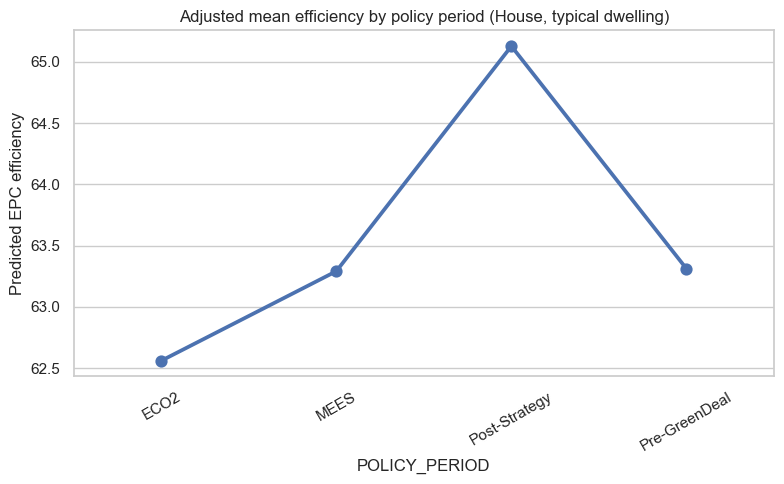

In [302]:
# Build a prediction grid over policy periods (average over other covariates)
pred_df = (
    df_model[["POLICY_PERIOD", "PROPERTY_TYPE", "TENURE_STD", "AGE_BAND_STD",
              "NUMBER_HABITABLE_ROOMS", "TOTAL_FLOOR_AREA"]]
    .copy()
)

# Set property type to most common (e.g. House) and tenure to "Owner-occupied"
pred_df["PROPERTY_TYPE"] = "House"
pred_df["TENURE_STD"] = "Owner-occupied"

# Use median age band and median rooms/area
pred_df["AGE_BAND_STD"] = df_model["AGE_BAND_STD"].mode()[0]
pred_df["NUMBER_HABITABLE_ROOMS"] = df_model["NUMBER_HABITABLE_ROOMS"].median()
pred_df["TOTAL_FLOOR_AREA"] = df_model["TOTAL_FLOOR_AREA"].median()

# Keep one row per policy period
pred_df = pred_df.drop_duplicates(subset=["POLICY_PERIOD"]).copy()

# ✅ Predict using the MixedLMResults object
pred_df["pred_eff"] = result.predict(exog=pred_df)

pred_df_sorted = pred_df.sort_values("POLICY_PERIOD")

plt.figure(figsize=(8,5))
sns.pointplot(
    data=pred_df_sorted,
    x="POLICY_PERIOD",
    y="pred_eff",
    join=True
)
plt.xticks(rotation=30)
plt.ylabel("Predicted EPC efficiency")
plt.title("Adjusted mean efficiency by policy period (House, typical dwelling)")
plt.tight_layout()
plt.show()

In [303]:
import statsmodels.formula.api as smf

fe_model = smf.ols(
    "CURRENT_ENERGY_EFFICIENCY ~ C(POLICY_PERIOD) + \
     C(PROPERTY_TYPE) + C(TENURE_STD) + C(AGE_BAND_STD) + \
     NUMBER_HABITABLE_ROOMS + TOTAL_FLOOR_AREA",
    data=df_model
).fit(cov_type="HC3")

print(fe_model.summary())

                                OLS Regression Results                               
Dep. Variable:     CURRENT_ENERGY_EFFICIENCY   R-squared:                       0.320
Model:                                   OLS   Adj. R-squared:                  0.320
Method:                        Least Squares   F-statistic:                 1.816e+04
Date:                       Tue, 09 Dec 2025   Prob (F-statistic):               0.00
Time:                               13:05:03   Log-Likelihood:            -2.5740e+06
No. Observations:                     730609   AIC:                         5.148e+06
Df Residuals:                         730584   BIC:                         5.148e+06
Df Model:                                 24                                         
Covariance Type:                         HC3                                         
                                                         coef    std err          z      P>|z|      [0.025      0.975]
---------------------

In [304]:
import numpy as np

print("=== MODEL COMPARISON ===")
print(f"OLS AIC:   {fe_model.aic:,.0f}")
print(f"OLS BIC:   {fe_model.bic:,.0f}")
print("\nMixed Model:")
print(f"Mixed AIC: {result.aic:,.0f}")
print(f"Mixed BIC: {result.bic:,.0f}")

# --- Pseudo R² for mixed model ---

# OLS sum of squared residuals (this exists)
fe_ss = fe_model.ssr

# Mixed model residuals -> sum of squared residuals
mixed_resid = result.resid          # vector of residuals
mixed_ss = np.sum(mixed_resid**2)   # SSE for mixed model

# Total sum of squares from the raw outcome
y = df_model["CURRENT_ENERGY_EFFICIENCY"]
total_ss = ((y - y.mean())**2).sum()

pseudo_r2_mixed = 1 - (mixed_ss / total_ss)

print(f"\nOLS R²:          {fe_model.rsquared:.4f}")
print(f"Mixed pseudo-R²: {pseudo_r2_mixed:.4f}")

=== MODEL COMPARISON ===
OLS AIC:   5,148,069
OLS BIC:   5,148,357

Mixed Model:
Mixed AIC: nan
Mixed BIC: nan

OLS R²:          0.3197
Mixed pseudo-R²: 0.3325


In [305]:
import statsmodels.formula.api as smf

rs_model = smf.mixedlm(
    "CURRENT_ENERGY_EFFICIENCY ~ C(POLICY_PERIOD) + \
     C(PROPERTY_TYPE) + C(TENURE_STD) + C(AGE_BAND_STD) + \
     NUMBER_HABITABLE_ROOMS + TOTAL_FLOOR_AREA",
    data=df_model,
    groups=df_model["LOCAL_AUTHORITY"],
    re_formula="~C(POLICY_PERIOD)"
).fit(reml=True)

print(rs_model.summary())

/Users/divyanshu/.pyenv/versions/3.11.9/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/divyanshu/.pyenv/versions/3.11.9/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(


                                         Mixed Linear Model Regression Results
Model:                             MixedLM                 Dependent Variable:                 CURRENT_ENERGY_EFFICIENCY
No. Observations:                  730609                  Method:                             REML                     
No. Groups:                        12                      Scale:                              65.8895                  
Min. group size:                   26710                   Log-Likelihood:                     -2566698.1877            
Max. group size:                   101784                  Converged:                          Yes                      
Mean group size:                   60884.1                                                                              
------------------------------------------------------------------------------------------------------------------------
                                                                          

In [306]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Unique policy periods (sorted for nicer plotting)
policies = sorted(df_model["POLICY_PERIOD"].unique())

pred_df = pd.DataFrame({"POLICY_PERIOD": policies})

# Typical dwelling
pred_df["PROPERTY_TYPE"] = "House"
pred_df["TENURE_STD"] = "Owner-occupied"
pred_df["AGE_BAND_STD"] = df_model["AGE_BAND_STD"].mode()[0]
pred_df["NUMBER_HABITABLE_ROOMS"] = df_model["NUMBER_HABITABLE_ROOMS"].median()
pred_df["TOTAL_FLOOR_AREA"] = df_model["TOTAL_FLOOR_AREA"].median()

pred_df

,POLICY_PERIOD,PROPERTY_TYPE,TENURE_STD,AGE_BAND_STD,NUMBER_HABITABLE_ROOMS,TOTAL_FLOOR_AREA
0,ECO2,House,Owner-occupied,England and Wales: 1950-1966,4.0,75.55
1,MEES,House,Owner-occupied,England and Wales: 1950-1966,4.0,75.55
2,Post-Strategy,House,Owner-occupied,England and Wales: 1950-1966,4.0,75.55
3,Pre-GreenDeal,House,Owner-occupied,England and Wales: 1950-1966,4.0,75.55


In [307]:
fe_model = smf.ols(
    "CURRENT_ENERGY_EFFICIENCY ~ C(POLICY_PERIOD) + \
     C(PROPERTY_TYPE) + C(TENURE_STD) + C(AGE_BAND_STD) + \
     NUMBER_HABITABLE_ROOMS + TOTAL_FLOOR_AREA",
    data=df_model
).fit(cov_type="HC3")

In [308]:
# Get prediction object
pred_res = fe_model.get_prediction(pred_df)

# Extract mean and CI
pred_df["pred"] = pred_res.predicted_mean
ci = pred_res.conf_int(alpha=0.05)
pred_df["lower"] = ci[:, 0]
pred_df["upper"] = ci[:, 1]

pred_df

,POLICY_PERIOD,PROPERTY_TYPE,TENURE_STD,AGE_BAND_STD,NUMBER_HABITABLE_ROOMS,TOTAL_FLOOR_AREA,pred,lower,upper
0,ECO2,House,Owner-occupied,England and Wales: 1950-1966,4.0,75.55,62.543160,62.444482,62.641838
1,MEES,House,Owner-occupied,England and Wales: 1950-1966,4.0,75.55,63.238062,63.109677,63.366446
2,Post-Strategy,House,Owner-occupied,England and Wales: 1950-1966,4.0,75.55,65.116517,65.053692,65.179342
3,Pre-GreenDeal,House,Owner-occupied,England and Wales: 1950-1966,4.0,75.55,63.284706,63.219504,63.349908


/var/folders/gs/6gjhnpdn0zd0p99jkjwdr0700000gn/T/ipykernel_1044/3241694071.py:4: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0.

  sns.pointplot(


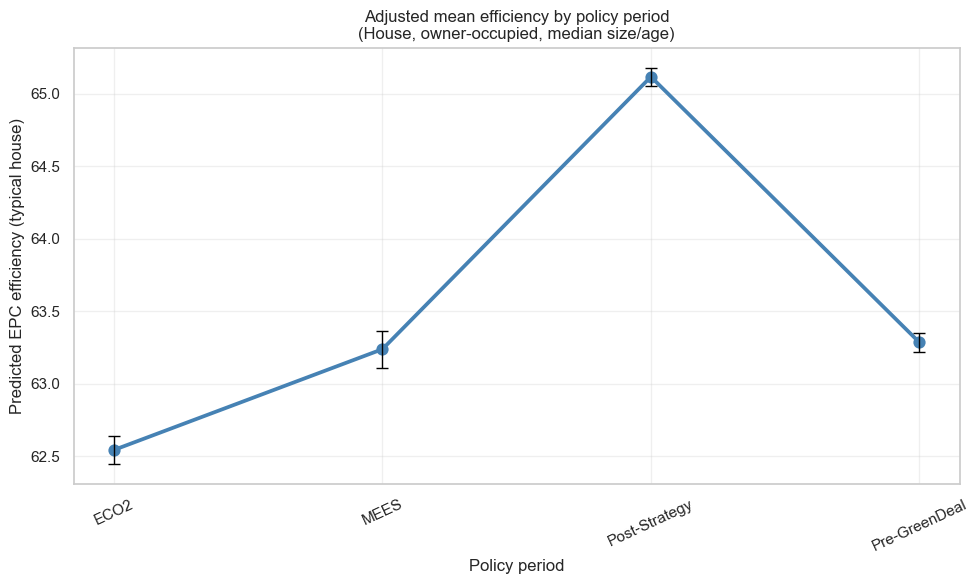

In [309]:
plt.figure(figsize=(10,6))

# point estimates
sns.pointplot(
    data=pred_df,
    x="POLICY_PERIOD",
    y="pred",
    join=True,
    color="steelblue"
)

# add error bars
plt.errorbar(
    pred_df["POLICY_PERIOD"],
    pred_df["pred"],
    yerr=[pred_df["pred"] - pred_df["lower"],
          pred_df["upper"] - pred_df["pred"]],
    fmt="none",
    ecolor="black",
    capsize=4,
    linewidth=1
)

plt.ylabel("Predicted EPC efficiency (typical house)")
plt.xlabel("Policy period")
plt.title("Adjusted mean efficiency by policy period\n"
          "(House, owner-occupied, median size/age)")
plt.xticks(rotation=25)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [310]:
import pandas as pd

# 1. Random effects from the mixed model (dict: {LA: Series})
re_dict = result.random_effects

# 2. Turn into DataFrame
re_df = pd.DataFrame(re_dict).T  # index = LA code, columns = random-effect terms
re_df.index.name = "LOCAL_AUTHORITY"

print("Random effects head:")
print(re_df.head())
print("\nColumns:", list(re_df.columns))

Random effects head:
                                        Group
LOCAL_AUTHORITY                              
Bath and North East Somerset         0.586692
Bournemouth, Christchurch and Poole  0.356914
Bristol, City of                     0.574379
Cornwall                            -2.879127
Dorset                              -0.255344

Columns: ['Group']


In [311]:
import statsmodels.formula.api as smf
import statsmodels.api as sm

# Random slopes for major policy periods
re_formula = "C(POLICY_PERIOD)"

mixed_rs = sm.MixedLM.from_formula(
    "CURRENT_ENERGY_EFFICIENCY ~ C(POLICY_PERIOD) + C(PROPERTY_TYPE) + "
    "C(TENURE_STD) + C(AGE_BAND_STD) + NUMBER_HABITABLE_ROOMS + TOTAL_FLOOR_AREA",
    groups="LOCAL_AUTHORITY",
    re_formula=re_formula,
    data=df_model
)

result_rs = mixed_rs.fit(method='lbfgs')
print(result_rs.summary())

                                         Mixed Linear Model Regression Results
Model:                             MixedLM                 Dependent Variable:                 CURRENT_ENERGY_EFFICIENCY
No. Observations:                  730609                  Method:                             REML                     
No. Groups:                        12                      Scale:                              65.8894                  
Min. group size:                   26710                   Log-Likelihood:                     -2566698.1685            
Max. group size:                   101784                  Converged:                          Yes                      
Mean group size:                   60884.1                                                                              
------------------------------------------------------------------------------------------------------------------------
                                                                          

In [312]:
import pandas as pd

# 1. Get random effects dict and convert to DataFrame
re_dict = result.random_effects  # LA -> Series of REs
re_df = pd.DataFrame(re_dict).T
re_df.index.name = "LOCAL_AUTHORITY"
re_df = re_df.reset_index()

print(re_df.head())
print("Columns:", re_df.columns.tolist())

                       LOCAL_AUTHORITY     Group
0         Bath and North East Somerset  0.586692
1  Bournemouth, Christchurch and Poole  0.356914
2                     Bristol, City of  0.574379
3                             Cornwall -2.879127
4                               Dorset -0.255344
Columns: ['LOCAL_AUTHORITY', 'Group']


In [313]:
import statsmodels.formula.api as smf

formula = """
CURRENT_ENERGY_EFFICIENCY ~ 
    C(POLICY_PERIOD) +
    C(PROPERTY_TYPE) +
    C(TENURE_STD) +
    C(AGE_BAND_STD) +
    NUMBER_HABITABLE_ROOMS +
    TOTAL_FLOOR_AREA
"""

re_formula = "1 + C(POLICY_PERIOD)"

mixed_rs = smf.mixedlm(
    formula=formula,
    data=df_model,
    groups=df_model["LOCAL_AUTHORITY"],
    re_formula=re_formula
)

result = mixed_rs.fit(method="lbfgs")
print(result.summary())

                                         Mixed Linear Model Regression Results
Model:                             MixedLM                 Dependent Variable:                 CURRENT_ENERGY_EFFICIENCY
No. Observations:                  730609                  Method:                             REML                     
No. Groups:                        12                      Scale:                              65.8894                  
Min. group size:                   26710                   Log-Likelihood:                     -2566698.1685            
Max. group size:                   101784                  Converged:                          Yes                      
Mean group size:                   60884.1                                                                              
------------------------------------------------------------------------------------------------------------------------
                                                                          

In [314]:
print(result.random_effects)

{'E06000022': Group                                0.301206
C(POLICY_PERIOD)[T.MEES]            -0.382992
C(POLICY_PERIOD)[T.Post-Strategy]    0.264802
C(POLICY_PERIOD)[T.Pre-GreenDeal]    0.378447
dtype: float64, 'E06000023': Group                                0.837392
C(POLICY_PERIOD)[T.MEES]            -0.732281
C(POLICY_PERIOD)[T.Post-Strategy]   -0.195238
C(POLICY_PERIOD)[T.Pre-GreenDeal]   -0.332479
dtype: float64, 'E06000024': Group                                0.933986
C(POLICY_PERIOD)[T.MEES]            -0.720460
C(POLICY_PERIOD)[T.Post-Strategy]   -0.350644
C(POLICY_PERIOD)[T.Pre-GreenDeal]   -0.969693
dtype: float64, 'E06000025': Group                               -0.608066
C(POLICY_PERIOD)[T.MEES]             0.482106
C(POLICY_PERIOD)[T.Post-Strategy]    0.687843
C(POLICY_PERIOD)[T.Pre-GreenDeal]   -0.026294
dtype: float64, 'E06000026': Group                                0.956463
C(POLICY_PERIOD)[T.MEES]            -0.013400
C(POLICY_PERIOD)[T.Post-Strategy]    0.358

In [315]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Convert your dict to DataFrame
re_df = pd.DataFrame(result.random_effects).T.reset_index()
re_df = re_df.rename(columns={"index": "LA_CODE"})

# Add LA names manually
la_map = {
    "E06000022": "Bath NE Somerset",
    "E06000023": "Bristol",
    "E06000024": "North Somerset",
    "E06000025": "Plymouth",
    "E06000026": "Torbay",
    "E06000027": "Cornwall",
    "E06000030": "Swindon",
    "E06000052": "Wiltshire",
    "E06000054": "BCP",
    "E06000058": "Somerset",
    "E06000059": "South Glos",
    "E06000066": "Dorset"
}

re_df["LOCAL_AUTHORITY"] = re_df["LA_CODE"].map(la_map)

# Select columns
slope_cols = [
    "Group",
    "C(POLICY_PERIOD)[T.MEES]",
    "C(POLICY_PERIOD)[T.Post-Strategy]",
    "C(POLICY_PERIOD)[T.Pre-GreenDeal]",
]

X = re_df[slope_cols].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42, n_init="auto")
re_df["cluster"] = kmeans.fit_predict(X_scaled)

re_df

,LA_CODE,Group,C(POLICY_PERIOD)[T.MEES],C(POLICY_PERIOD)[T.Post-Strategy],C(POLICY_PERIOD)[T.Pre-GreenDeal],LOCAL_AUTHORITY,cluster
0,E06000022,0.301206,-0.382992,0.264802,0.378447,Bath NE Somerset,2
1,E06000023,0.837392,-0.732281,-0.195238,-0.332479,Bristol,0
2,E06000024,0.933986,-0.720460,-0.350644,-0.969693,North Somerset,0
3,E06000025,-0.608066,0.482106,0.687843,-0.026294,Plymouth,2
4,E06000026,0.956463,-0.013400,0.358696,-0.353356,Torbay,0
5,E06000027,-0.409875,0.189882,0.012233,0.145369,Cornwall,2
6,E06000030,-0.003997,1.503313,0.766649,0.992914,Swindon,2
7,E06000052,-2.440333,-1.223229,-0.921302,0.280669,Wiltshire,1
8,E06000054,-0.348857,0.511692,-0.021956,0.032974,BCP,2
9,E06000058,0.149105,0.731755,0.107829,0.323641,Somerset,2


Explained variance by PC1, PC2: [0.555 0.344]


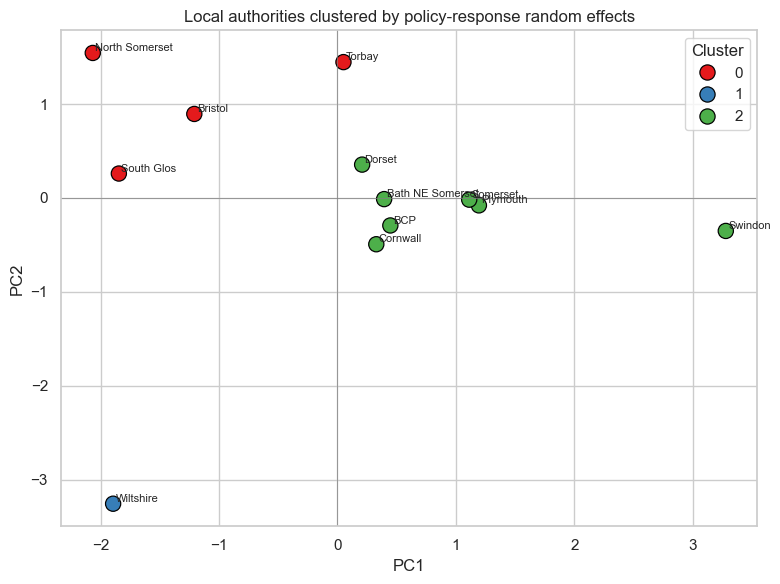

In [316]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# --- 1. Select random-effect features (baseline + slopes) ---
slope_cols = [
    "Group",
    "C(POLICY_PERIOD)[T.MEES]",
    "C(POLICY_PERIOD)[T.Post-Strategy]",
    "C(POLICY_PERIOD)[T.Pre-GreenDeal]",
]

X = re_df[slope_cols].values

# --- 2. Standardise before PCA ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- 3. PCA to 2D for plotting ---
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

df_pca = re_df.copy()
df_pca["PC1"] = X_pca[:, 0]
df_pca["PC2"] = X_pca[:, 1]

print("Explained variance by PC1, PC2:",
      np.round(pca.explained_variance_ratio_, 3))

# --- 4. Scatter plot, coloured by cluster, labelled by LA ---
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_pca,
    x="PC1",
    y="PC2",
    hue="cluster",
    palette="Set1",
    s=120,
    edgecolor="black"
)

for _, row in df_pca.iterrows():
    plt.text(
        row["PC1"] + 0.02,
        row["PC2"] + 0.02,
        row["LOCAL_AUTHORITY"],
        fontsize=8
    )

plt.axhline(0, color="grey", linewidth=0.5)
plt.axvline(0, color="grey", linewidth=0.5)
plt.title("Local authorities clustered by policy-response random effects")
plt.tight_layout()
plt.legend(title="Cluster")
plt.show()

In [317]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, re_df["cluster"])
print("Silhouette Score:", score)

Silhouette Score: 0.33849979671349995


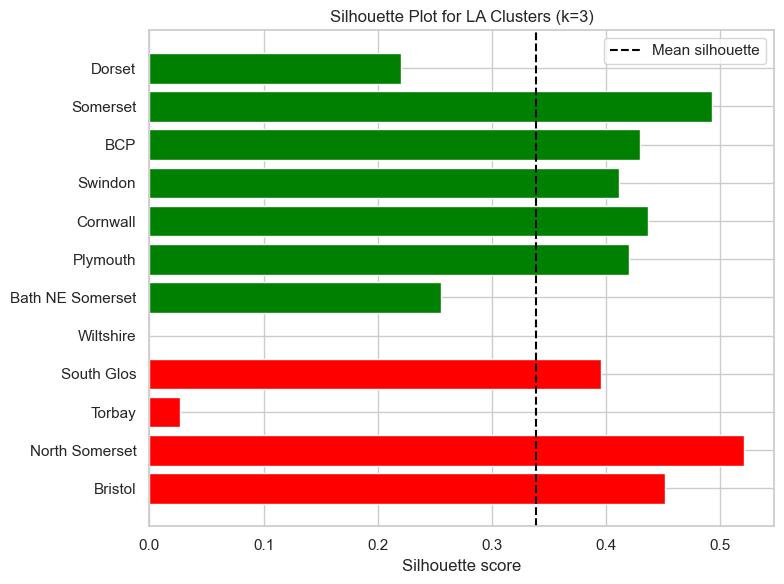

Mean Silhouette Score: 0.33849979671349995


In [318]:
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_samples, silhouette_score
import numpy as np

# X_scaled: scaled random-effect slopes (same as you used for KMeans)
# re_df: dataframe with LA names, clusters, and random effects
# re_df["cluster"] already exists from KMeans

clusters = re_df["cluster"].to_numpy()        # <- use the column
X_scaled = X_scaled                           # whatever you computed before

# Compute silhouette values
sil_vals = silhouette_samples(X_scaled, clusters)

# Sort by cluster for nicer plotting
order = np.argsort(clusters)
sil_sorted = sil_vals[order]
cluster_sorted = clusters[order]
la_sorted = re_df["LOCAL_AUTHORITY"].values[order]

plt.figure(figsize=(8, 6))
y_pos = np.arange(len(sil_sorted))

# Colour by cluster (k=3)
colors = ['red', 'blue', 'green']
cluster_colors = [colors[c] for c in cluster_sorted]

plt.barh(y_pos, sil_sorted, color=cluster_colors)
plt.yticks(y_pos, la_sorted)
plt.axvline(x=np.mean(sil_vals),
            color="black", linestyle="--", label="Mean silhouette")

plt.xlabel("Silhouette score")
plt.title("Silhouette Plot for LA Clusters (k=3)")
plt.legend()
plt.tight_layout()
plt.show()

print("Mean Silhouette Score:", np.mean(sil_vals))

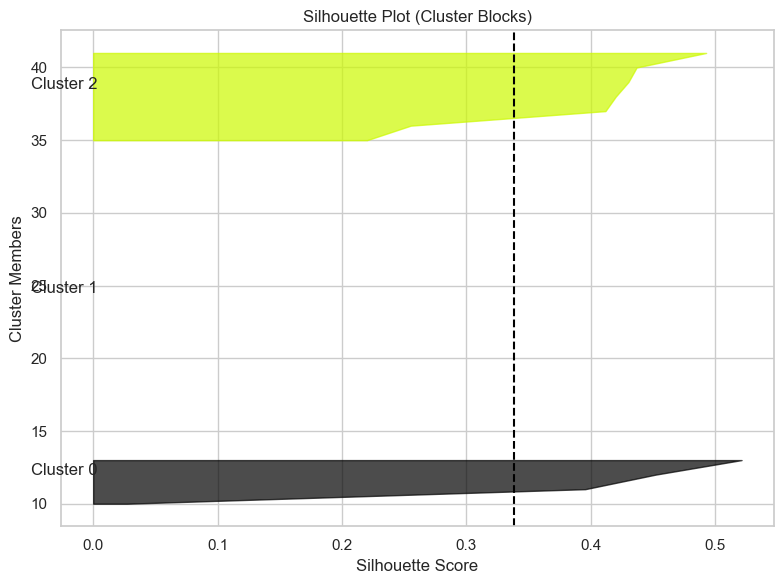

In [319]:
from matplotlib import cm

n_clusters = len(np.unique(df_pca["cluster"]))
fig, ax = plt.subplots(figsize=(8, 6))

y_lower = 10
for i in range(n_clusters):
    ith_cluster_sil = sil_vals[df_pca["cluster"] == i]
    ith_cluster_sil.sort()
    size_cluster_i = ith_cluster_sil.shape[0]
    y_upper = y_lower + size_cluster_i
    
    color = cm.nipy_spectral(float(i) / n_clusters)
    ax.fill_betweenx(np.arange(y_lower, y_upper),
                     0, ith_cluster_sil,
                     facecolor=color, edgecolor=color, alpha=0.7)

    ax.text(-0.05, y_lower + 0.5 * size_cluster_i, f"Cluster {i}")
    
    y_lower = y_upper + 10  # spacing between clusters

ax.axvline(x=np.mean(sil_vals), color="black", linestyle="--")
ax.set_xlabel("Silhouette Score")
ax.set_ylabel("Cluster Members")
ax.set_title("Silhouette Plot (Cluster Blocks)")
plt.tight_layout()
plt.show()

In [320]:
df

,LMK_KEY,POSTCODE,LOCAL_AUTHORITY,LOCAL_AUTHORITY_LABEL,LODGEMENT_DATE,CURRENT_ENERGY_RATING,CURRENT_ENERGY_EFFICIENCY,POTENTIAL_ENERGY_RATING,POTENTIAL_ENERGY_EFFICIENCY,ENERGY_CONSUMPTION_CURRENT,...,MAIN_FUEL_STD,TENURE_STD,AGE_BAND_STD,EFFICIENCY_GAP,EPC_BAND_SCORE,HAS_MAINS_GAS,IS_ELECTRIC_HEAT,BELOW_C,POLICY_PERIOD,MEES_PERIOD
1164,150924580062008100113401071698148,SN12 8QF,E06000054,Wiltshire,2008-10-01 00:00:00+00:00,D,62,C,73,267,...,other,Owner-occupied,England and Wales: before 1900,11,4,True,False,True,Pre-GreenDeal,Pre
19041,157572380062008100123465541498988,BS22 9QD,E06000024,North Somerset,2008-10-01 00:00:00+00:00,D,67,C,72,257,...,other,Owner-occupied,England and Wales: 1983-1990,5,4,True,False,True,Pre-GreenDeal,Pre
32090,143095058052008100121582305089951,BH8 8TW,E06000058,"Bournemouth, Christchurch and Poole",2008-10-01 00:00:00+00:00,C,76,B,83,222,...,other,Owner-occupied,England and Wales: 1996-2002,7,5,True,False,False,Pre-GreenDeal,Pre
39065,156772120832008100115074508068395,BA1 5RJ,E06000022,Bath and North East Somerset,2008-10-01 00:00:00+00:00,E,52,D,61,387,...,other,Rented (private),England and Wales: 1950-1966,9,3,True,False,True,Pre-GreenDeal,Pre
1695,146847250922008100117310071758748,BA2 5RB,E06000022,Bath and North East Somerset,2008-10-01 00:00:00+00:00,D,58,D,58,475,...,other,Owner-occupied,England and Wales: before 1900,0,4,False,False,True,Pre-GreenDeal,Pre
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1800468,4972b2e492a0eb5bd79540d2e3cda5c10de280d182129e...,BH31 6DP,E06000059,Dorset,2025-09-30 00:00:00+00:00,C,73,C,76,170,...,gas,Unknown,England and Wales: 1991-1995,3,5,True,False,False,Post-Strategy,Post
1800488,49ab78fc85e153db29d32c73937824ce8858398ae678b2...,TA1 1AR,E06000066,Somerset,2025-09-30 00:00:00+00:00,C,79,C,79,91,...,gas,Unknown,England and Wales: 2012-2021,0,5,True,False,False,Post-Strategy,Post
1803950,aadd12ba63b55d16af2b0380823dc735f04b14dd048c0d...,SN5 8DU,E06000030,Swindon,2025-09-30 00:00:00+00:00,D,67,C,79,224,...,gas,Owner-occupied,England and Wales: 1976-1982,12,4,True,False,True,Post-Strategy,Post
1803928,a9d5554ba4f0aee31e12c98706fab0601ecea608a0f694...,TA6 6EH,E06000066,Somerset,2025-09-30 00:00:00+00:00,C,74,C,76,154,...,gas,Unknown,England and Wales: 1950-1966,2,5,True,False,False,Post-Strategy,Post
